In [1]:
!pip -q install brian2 cirq qsimcirq transformers accelerate datasets sentencepiece \
    openai-whisper ffmpeg-python torchaudio soundfile \
    open-clip-torch timm opencv-python decord

# System dependency: ffmpeg
import shutil, os, sys, subprocess
if shutil.which("ffmpeg") is None:
    print("ffmpeg not found. Install it on your OS:")
    print("  Ubuntu: sudo apt-get update && sudo apt-get install -y ffmpeg")
    print("  macOS:  brew install ffmpeg")
    print("  Win:    choco install ffmpeg")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 10.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00

In [4]:
import zipfile, os, json, glob

zip_path = "./synthdata.zip"  # Corrected path
out_dir = "./data"

os.makedirs(out_dir, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(out_dir)

root = os.path.join(out_dir, "synthdata", "synth")
print("Root:", root)
print("Files:", sorted(os.listdir(root))[:20])

manifest = os.path.join(root, "manifest.jsonl")
print("Manifest exists:", os.path.exists(manifest))
print("Example line:", open(manifest, "r", encoding="utf-8").readline()[:200])

Root: ./data/synthdata/synth
Files: ['E_aud.npy', 'E_img.npy', 'E_text.npy', 'E_vid.npy', 'audio', 'haptics', 'images', 'manifest.jsonl', 'text', 'video']
Manifest exists: True
Example line: {"i": 0, "timestamp": "2025-08-17T09:56:43.222236", "script_name": "model", "script_id": 4, "cycle": 1, "text": "[model] cycle=1 mood=drifting. classical(H=0.714, M=0.733, S=0.709) quantum(H=0.376, M=


In [5]:
import shutil
!pip -q install brian2 cirq qsimcirq transformers accelerate sentencepiece \
    openai-whisper ffmpeg-python torchaudio soundfile \
    open-clip-torch opencv-python decord pillow

# System dependency: ffmpeg
if shutil.which("ffmpeg") is None:
    print("ffmpeg not found on OS. Install it:")
    print("Ubuntu: sudo apt-get update && sudo apt-get install -y ffmpeg")
    print("macOS:  brew install ffmpeg")
    print("Win:    choco install ffmpeg")

In [6]:
!apt-get update -qq && apt-get install -qq -y ffmpeg

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [7]:
import os, zipfile, json, numpy as np, pathlib, shutil

ZIP_PATH = "/content/data/synthdata.zip"  # Corrected path
OUT_DIR  = "./data"

os.makedirs(OUT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(OUT_DIR)

ROOT = os.path.join(OUT_DIR, "synthdata", "synth")
manifest_path = os.path.join(ROOT, "manifest.jsonl")

print("ROOT:", ROOT)
print("ROOT contents:", sorted(os.listdir(ROOT)))
print("Manifest:", manifest_path, "exists:", os.path.exists(manifest_path))

items=[]
with open(manifest_path, "r", encoding="utf-8") as f:
    for line in f:
        j=json.loads(line)
        items.append(j)

print("N items:", len(items))
print("Example:", items[0])

ROOT: ./data/synthdata/synth
ROOT contents: ['E_aud.npy', 'E_img.npy', 'E_text.npy', 'E_vid.npy', 'audio', 'haptics', 'images', 'manifest.jsonl', 'text', 'video']
Manifest: ./data/synthdata/synth/manifest.jsonl exists: True
N items: 49
Example: {'i': 0, 'timestamp': '2025-08-17T09:56:43.222236', 'script_name': 'model', 'script_id': 4, 'cycle': 1, 'text': '[model] cycle=1 mood=drifting. classical(H=0.714, M=0.733, S=0.709) quantum(H=0.376, M=0.328, S=0.240).', 'image_path': '/content/synth/images/model_c000001_0000000.png', 'audio_path': '/content/synth/audio/model_c000001_0000000.wav', 'video_path': '/content/synth/video/model_c000001_0000000.mp4'}


In [8]:
def fix_path(p: str) -> str:
    # manifest has /content/synth/images/...
    # your extracted tree is ROOT/images/...
    if p.startswith("/content/synth/"):
        rel = p.replace("/content/synth/", "")
        return os.path.join(ROOT, rel)
    return p

def get_paths(items):
    texts, imgs, auds, vids = [], [], [], []
    for j in items:
        texts.append(j["text"])
        imgs.append(fix_path(j["image_path"]))
        auds.append(fix_path(j["audio_path"]))
        vids.append(fix_path(j["video_path"]))
    return texts, imgs, auds, vids

texts, img_paths, aud_paths, vid_paths = get_paths(items)

print(img_paths[0], os.path.exists(img_paths[0]))
print(aud_paths[0], os.path.exists(aud_paths[0]))
print(vid_paths[0], os.path.exists(vid_paths[0]))

./data/synthdata/synth/images/model_c000001_0000000.png True
./data/synthdata/synth/audio/model_c000001_0000000.wav True
./data/synthdata/synth/video/model_c000001_0000000.mp4 True


In [9]:
import torch
from transformers import AutoTokenizer, AutoModel

torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
whisper_device = "cuda" if torch.cuda.is_available() else "cpu"
txt_name = "sentence-transformers/all-MiniLM-L6-v2"

txt_tok = AutoTokenizer.from_pretrained(txt_name)
txt_model = AutoModel.from_pretrained(txt_name).to(torch_device).eval()

@torch.no_grad()
def embed_text(texts):
    batch = txt_tok(texts, padding=True, truncation=True, return_tensors="pt").to(torch_device)
    out = txt_model(**batch).last_hidden_state  # (B,T,H)
    mask = batch["attention_mask"].unsqueeze(-1)
    pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
    return torch.nn.functional.normalize(pooled, dim=-1)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
import open_clip
from PIL import Image
import torchvision.transforms as T

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="laion2b_s34b_b79k")
clip_model = clip_model.to(torch_device).eval()

@torch.no_grad()
def embed_image(paths):
    ims = [clip_preprocess(Image.open(p).convert("RGB")) for p in paths]
    x = torch.stack(ims).to(torch_device)
    z = clip_model.encode_image(x)
    return torch.nn.functional.normalize(z, dim=-1)


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [11]:
import whisper
import numpy as np

wh_model = whisper.load_model("base", device=whisper_device)

@torch.no_grad()
def embed_audio(paths):
    embs = []
    for p in paths:
        audio = whisper.load_audio(p)
        audio = whisper.pad_or_trim(audio)
        mel = whisper.log_mel_spectrogram(audio).to(torch_device)
        enc = wh_model.encoder(mel.unsqueeze(0))  # (1, frames, dim)
        emb = enc.mean(dim=1)                     # (1, dim)
        embs.append(emb.squeeze(0))
    embs = torch.stack(embs)
    return torch.nn.functional.normalize(embs, dim=-1)


100%|████████████████████████████████████████| 139M/139M [00:01<00:00, 140MiB/s]


In [12]:
import decord
decord.bridge.set_bridge("torch")

@torch.no_grad()
def embed_video(paths, num_frames=8):
    all_embs = []
    for p in paths:
        vr = decord.VideoReader(p)
        n = len(vr)
        idx = torch.linspace(0, max(n-1,0), steps=min(num_frames, n)).long()
        frames = vr.get_batch(idx).permute(0,3,1,2)  # (F,C,H,W)
        # preprocess like CLIP
        frames_pil = [T.ToPILImage()(f.cpu()) for f in frames]
        frames_t = torch.stack([clip_preprocess(im) for im in frames_pil]).to(torch_device)
        zf = clip_model.encode_image(frames_t)  # (F,D)
        zv = zf.mean(dim=0, keepdim=True)       # (1,D)
        all_embs.append(zv.squeeze(0))
    all_embs = torch.stack(all_embs)
    return torch.nn.functional.normalize(all_embs, dim=-1)


In [13]:
import numpy as np
from brian2 import *

def brian2_rate_features(x_np, sim_ms=50.0):
    """
    x_np: (B, D) numpy float32 in [-1,1] or [0,1]
    returns: (B, D) spike rates
    """
    B, D = x_np.shape
    # normalize to [0,1] current
    x = x_np
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)

    defaultclock.dt = 0.1*ms
    tau = 10*ms

    eqs = '''
    dv/dt = (-v + I)/tau : 1
    I : 1
    '''

    rates_out = []
    for b in range(B):
        G = NeuronGroup(D, eqs, threshold='v>1', reset='v=0', method='euler')
        G.I = x[b]
        M = SpikeMonitor(G)
        run(sim_ms*ms)
        # spikes per neuron / second
        rate = np.array(M.count) / (sim_ms/1000.0)
        rates_out.append(rate.astype(np.float32))
        # reset Brian2 state between samples
        brian2_device.reinit()
        brian2_device.activate()
    return np.stack(rates_out, axis=0)

In [14]:
import torch
from transformers import AutoTokenizer, AutoModel

torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
whisper_device = "cuda" if torch.cuda.is_available() else "cpu"

TEXT_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
txt_tok = AutoTokenizer.from_pretrained(TEXT_MODEL)
txt_model = AutoModel.from_pretrained(TEXT_MODEL).to(torch_device).eval()

@torch.no_grad()
def embed_text(batch_texts):
    batch = txt_tok(batch_texts, padding=True, truncation=True, return_tensors="pt").to(torch_device)
    out = txt_model(**batch).last_hidden_state  # (B,T,H)
    mask = batch["attention_mask"].unsqueeze(-1)
    pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
    return torch.nn.functional.normalize(pooled, dim=-1)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
import open_clip
from PIL import Image

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="laion2b_s34b_b79k"
)
clip_model = clip_model.to(torch_device).eval()

@torch.no_grad()
def embed_images(paths):
    ims = [clip_preprocess(Image.open(p).convert("RGB")) for p in paths]
    x = torch.stack(ims).to(torch_device)
    z = clip_model.encode_image(x)
    return torch.nn.functional.normalize(z, dim=-1)

In [16]:
import whisper

wh_model = whisper.load_model("base", device=whisper_device)

@torch.no_grad()
def embed_audio(paths):
    embs = []
    for p in paths:
        audio = whisper.load_audio(p)
        audio = whisper.pad_or_trim(audio)
        mel = whisper.log_mel_spectrogram(audio).to(torch_device)
        enc = wh_model.encoder(mel.unsqueeze(0))   # (1, frames, dim)
        emb = enc.mean(dim=1).squeeze(0)          # (dim,)
        embs.append(emb)
    embs = torch.stack(embs)
    return torch.nn.functional.normalize(embs, dim=-1)

In [17]:
import decord
import torchvision.transforms as T
decord.bridge.set_bridge("torch")

@torch.no_grad()
def embed_video(paths, num_frames=8):
    all_embs = []
    for p in paths:
        vr = decord.VideoReader(p)
        n = len(vr)
        idx = torch.linspace(0, max(n-1, 0), steps=min(num_frames, n)).long()
        frames = vr.get_batch(idx).permute(0,3,1,2)  # (F,C,H,W)
        frames_pil = [T.ToPILImage()(f.cpu()) for f in frames]
        frames_t = torch.stack([clip_preprocess(im) for im in frames_pil]).to(torch_device)
        zf = clip_model.encode_image(frames_t)  # (F,D)
        zv = zf.mean(dim=0)
        all_embs.append(zv)
    all_embs = torch.stack(all_embs)
    return torch.nn.functional.normalize(all_embs, dim=-1)

In [18]:
from transformers import pipeline
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
sent_pipe = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", device=0 if device=="cuda" else -1)

def sentiment_scores(texts):
    # returns float in [0,1] where 1=positive
    outs = sent_pipe(texts, truncation=True)
    scores = []
    for o in outs:
        if o["label"].upper().startswith("POS"):
            scores.append(float(o["score"]))
        else:
            scores.append(1.0 - float(o["score"]))
    return np.array(scores, dtype=np.float32)

s_scores = sentiment_scores(texts)
print("Sentiment scores (first 5):", s_scores[:5])
print("Average sentiment score:", s_scores.mean())

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Sentiment scores (first 5): [0.00513488 0.00370187 0.00497109 0.00513488 0.00445032]
Average sentiment score: 0.25469378


In [19]:
import torch
import soundfile as sf
import numpy as np

HAPT_DIR = os.path.join(ROOT, "haptics")
os.makedirs(HAPT_DIR, exist_ok=True)

def gen_haptics_for_audio(wav_path, sentiment, T=200):
    audio, sr = sf.read(wav_path, dtype="float32", always_2d=True)
    wav = torch.tensor(audio).T  # (ch,n)
    wav = wav.mean(dim=0)                # mono
    # energy envelope
    hop = max(1, wav.shape[0] // T)
    env = []
    for i in range(T):
        seg = wav[i*hop:(i+1)*hop]
        env.append(seg.abs().mean().item() if seg.numel() else 0.0)
    env = np.array(env, dtype=np.float32)
    env = (env - env.min()) / (env.max() - env.min() + 1e-8)

    # sentiment modulates "smoothness" and intensity
    vib = np.clip(0.2 + 0.8*(0.6*env + 0.4*sentiment), 0, 1)

    # pulse proxy: more pulses if negative/tense (1-sentiment)
    pulse = np.clip((1.0 - sentiment) * (0.3 + 0.7*env), 0, 1)

    # pressure proxy: stable “force” tied to env but biased by sentiment
    force = np.clip(0.1 + 0.9*(0.7*env + 0.3*sentiment), 0, 1)

    return np.stack([vib, pulse, force], axis=1).astype(np.float32)

hapt_paths = []
for j, wav_path, s in zip(items, aud_paths, s_scores):
    hp = os.path.join(HAPT_DIR, f"{j['i']:04d}.npy")
    np.save(hp, gen_haptics_for_audio(wav_path, float(s), T=200))
    hapt_paths.append(hp)

print("Saved haptics:", hapt_paths[0], np.load(hapt_paths[0]).shape)

Saved haptics: ./data/synthdata/synth/haptics/0000.npy (200, 3)


In [20]:
import torch.nn as nn
import torch.nn.functional as F

class HapticsEncoder(nn.Module):
    def __init__(self, in_ch=3, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.proj = nn.Linear(64, out_dim)

    def forward(self, x):  # x: (B,T,C)
        x = x.transpose(1,2)        # (B,C,T)
        h = self.net(x).squeeze(-1) # (B,64)
        z = self.proj(h)
        return F.normalize(z, dim=-1)

def load_haptics_batch(paths):
    arr = [np.load(p) for p in paths]  # each (T,3)
    x = torch.tensor(np.stack(arr, axis=0), dtype=torch.float32, device=torch_device)
    return x

In [21]:
from brian2 import *
import numpy as np

def brian2_rate_features(x_np, sim_ms=30.0):
    """
    x_np: (B, D) float32
    returns: (B, D) spike rates
    """
    B, D = x_np.shape
    x = x_np
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)

    defaultclock.dt = 0.1*ms
    tau = 10*ms
    eqs = '''
    dv/dt = (-v + I)/tau : 1
    I : 1
    '''

    rates_out = []
    for b in range(B):
        G = NeuronGroup(D, eqs, threshold='v>1', reset='v=0', method='euler')
        G.I = x[b]
        M = SpikeMonitor(G)
        run(sim_ms*ms)
        rate = np.array(M.count) / (sim_ms/1000.0)
        rates_out.append(rate.astype(np.float32))
        device.reinit(); device.activate()
    return np.stack(rates_out, axis=0)

In [22]:
import cirq, qsimcirq
import numpy as np

def quantum_features(x_np, n_qubits=8, reps=2):
    B, D = x_np.shape
    qubits = cirq.LineQubit.range(n_qubits)
    sim = qsimcirq.QSimSimulator()

    feats=[]
    for b in range(B):
        angles = x_np[b, :n_qubits]
        c = cirq.Circuit()
        for i,q in enumerate(qubits):
            c.append(cirq.ry(float(angles[i]))(q))
            c.append(cirq.rz(float(angles[i]))(q))
        for _ in range(reps):
            for i in range(n_qubits-1):
                c.append(cirq.CNOT(qubits[i], qubits[i+1]))
        r = sim.simulate(c)
        state = r.final_state_vector
        probs = np.abs(state)**2

        q0=[]
        for qi in range(n_qubits):
            mask = 1 << (n_qubits-1-qi)
            p0 = probs[[i for i in range(len(probs)) if (i & mask)==0]].sum()
            q0.append(p0)
        q0 = np.array(q0, dtype=np.float32)
        feats.append(np.concatenate([q0, 1.0-q0], axis=0))
    return np.stack(feats, axis=0)

In [23]:
import torch

E_t = embed_text(texts)
E_i = embed_images(img_paths)
E_a = embed_audio(aud_paths)
E_v = embed_video(vid_paths)

print(E_t.shape, E_i.shape, E_a.shape, E_v.shape)

torch.Size([49, 384]) torch.Size([49, 512]) torch.Size([49, 512]) torch.Size([49, 512])


In [24]:
import numpy as np

# --- Text synaptic+quantum augmentation (fast enough for N=49) ---
E_t_np = E_t.detach().cpu().numpy().astype(np.float32)

S_t = brian2_rate_features(E_t_np[:, :128], sim_ms=25.0)      # synaptic features
Q_t = quantum_features(E_t_np[:, :8], n_qubits=8, reps=2)     # quantum features

E_t_aug = torch.tensor(np.concatenate([E_t_np, S_t, Q_t], axis=1), device=torch_device, dtype=torch.float32)
E_t_aug = torch.nn.functional.normalize(E_t_aug, dim=-1)

print("E_t_aug:", E_t_aug.shape)

E_t_aug: torch.Size([49, 528])


In [25]:
import torch.nn as nn
import torch.nn.functional as F

class Projector(nn.Module):
    def __init__(self, in_dim, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim),
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

def info_nce(a, b, temp=0.07):
    logits = (a @ b.T) / temp
    labels = torch.arange(a.size(0), device=a.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2

h_enc = HapticsEncoder(in_ch=3, out_dim=256).to(torch_device)

p_t = Projector(E_t_aug.shape[1]).to(torch_device)
p_i = Projector(E_i.shape[1]).to(torch_device)
p_a = Projector(E_a.shape[1]).to(torch_device)
p_v = Projector(E_v.shape[1]).to(torch_device)

opt = torch.optim.AdamW(
    list(h_enc.parameters()) + list(p_t.parameters()) + list(p_i.parameters()) +
    list(p_a.parameters()) + list(p_v.parameters()),
    lr=2e-3, weight_decay=1e-4
)

H = load_haptics_batch(hapt_paths)      # (N,T,3)
N = E_i.shape[0]

for epoch in range(1, 4001):
    idx = torch.randperm(N, device=torch_device)

    zt = p_t(E_t_aug[idx])
    zi = p_i(E_i[idx])
    za = p_a(E_a[idx])
    zv = p_v(E_v[idx])
    zh = h_enc(H[idx])

    # all-pairs contrastive (5 modalities)
    loss = (
        info_nce(zt, zi) + info_nce(zt, za) + info_nce(zt, zv) + info_nce(zt, zh) +
        info_nce(zi, za) + info_nce(zi, zv) + info_nce(zi, zh) +
        info_nce(za, zv) + info_nce(za, zh) +
        info_nce(zv, zh)
    )

    opt.zero_grad()
    loss.backward()
    opt.step()

    if epoch % 50 == 0 or epoch == 1:
        print(f"epoch {epoch:4d}  loss {loss.item():.4f}")

epoch    1  loss 38.9333
epoch   50  loss 28.1392
epoch  100  loss 24.6681
epoch  150  loss 28.3145
epoch  200  loss 14.1899
epoch  250  loss 12.3578
epoch  300  loss 12.3061
epoch  350  loss 12.3381
epoch  400  loss 11.8285
epoch  450  loss 11.7804
epoch  500  loss 11.7940
epoch  550  loss 11.7005
epoch  600  loss 11.7417
epoch  650  loss 11.6888
epoch  700  loss 11.7633
epoch  750  loss 11.6710
epoch  800  loss 11.7192
epoch  850  loss 22.5307
epoch  900  loss 11.9904
epoch  950  loss 11.7568
epoch 1000  loss 11.6698
epoch 1050  loss 11.6609
epoch 1100  loss 11.6619
epoch 1150  loss 11.6530
epoch 1200  loss 11.6419
epoch 1250  loss 11.7498
epoch 1300  loss 11.6855
epoch 1350  loss 11.6557
epoch 1400  loss 11.6760
epoch 1450  loss 11.6574
epoch 1500  loss 11.6417
epoch 1550  loss 11.6340
epoch 1600  loss 11.6614
epoch 1650  loss 11.5970
epoch 1700  loss 11.6121
epoch 1750  loss 11.6368
epoch 1800  loss 11.6305
epoch 1850  loss 11.6209
epoch 1900  loss 11.5985
epoch 1950  loss 11.6071


In [26]:
@torch.no_grad()
def retrieve_text_to_video(query_text, topk=5):
    q = embed_text([query_text])
    # augment query in same way:
    q_np = q.detach().cpu().numpy().astype(np.float32)
    S_q = brian2_rate_features(q_np[:, :128], sim_ms=25.0)
    Q_q = quantum_features(q_np[:, :8], n_qubits=8, reps=2)
    q_aug = torch.tensor(np.concatenate([q_np, S_q, Q_q], axis=1), device=torch_device, dtype=torch.float32)
    q_aug = torch.nn.functional.normalize(q_aug, dim=-1)

    zq = p_t(q_aug)                # (1,256)
    zv_all = p_v(E_v)              # (N,256)
    sims = (zq @ zv_all.T).squeeze(0)
    vals, inds = torch.topk(sims, k=min(topk, len(sims)))
    return [(int(i.item()), float(v.item()), vid_paths[int(i.item())]) for v,i in zip(vals, inds)]

# Example usage:
print(retrieve_text_to_video("drifting mood model cycle", topk=5))

[(13, 0.7519037127494812, './data/synthdata/synth/video/client_c000001_0000013.mp4'), (15, 0.7519037127494812, './data/synthdata/synth/video/client_c000002_0000015.mp4'), (14, 0.7519037127494812, './data/synthdata/synth/video/client_c000002_0000014.mp4'), (2, 0.7519037127494812, './data/synthdata/synth/video/client_c000001_0000002.mp4'), (10, 0.6348665952682495, './data/synthdata/synth/video/cookie_c000002_0000010.mp4')]


Generating parallax view for the first image...


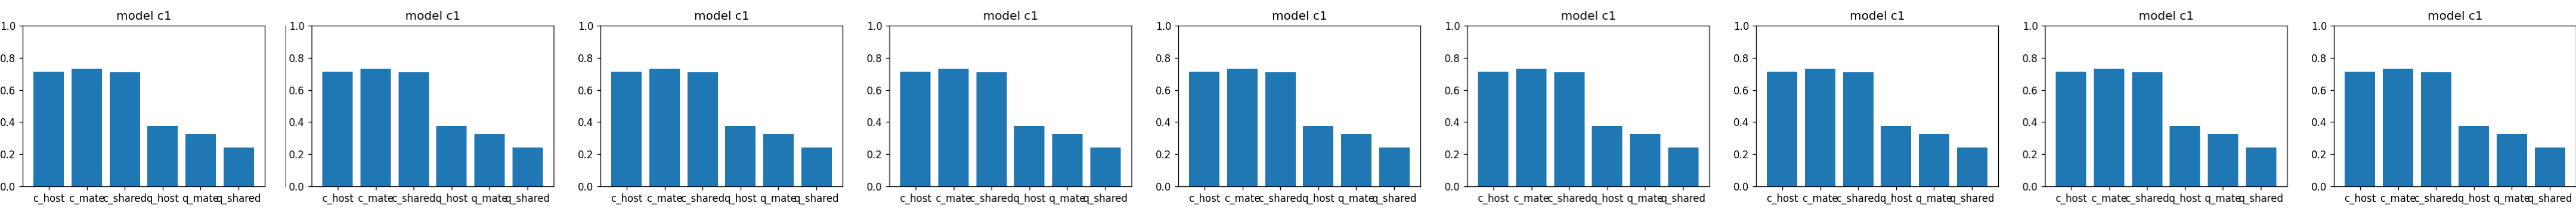

In [27]:
import cv2
import numpy as np
from PIL import Image

def parallax_views(img_path, n_views=9, max_shift=20):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h,w,_ = img.shape
    views=[]
    shifts = np.linspace(-max_shift, max_shift, n_views).astype(np.float32)

    for s in shifts:
        M = np.float32([[1,0,s],[0,1,0]])
        shifted = cv2.warpAffine(img, M, (w,h), borderMode=cv2.BORDER_REFLECT)
        views.append(shifted)
    grid = np.concatenate(views, axis=1)
    return Image.fromarray(grid)

# Show multi-view “holo strip” for a sample
print("Generating parallax view for the first image...")
parallax_views(img_paths[0], n_views=9, max_shift=18)

In [28]:
import numpy as np

# --- Text synaptic+quantum augmentation (fast enough for N=49) ---
E_t_np = E_t.detach().cpu().numpy().astype(np.float32)

S_t = brian2_rate_features(E_t_np[:, :128], sim_ms=25.0)      # synaptic features
Q_t = quantum_features(E_t_np[:, :8], n_qubits=8, reps=2)     # quantum features

E_t_aug = torch.tensor(np.concatenate([E_t_np, S_t, Q_t], axis=1), device=torch_device, dtype=torch.float32)
E_t_aug = torch.nn.functional.normalize(E_t_aug, dim=-1)

print("E_t_aug:", E_t_aug.shape)

E_t_aug: torch.Size([49, 528])


In [29]:
import torch.nn as nn
import torch.nn.functional as F

class Projector(nn.Module):
    def __init__(self, in_dim, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim),
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

def info_nce(a, b, temp=0.07):
    logits = (a @ b.T) / temp
    labels = torch.arange(a.size(0), device=a.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2

h_enc = HapticsEncoder(in_ch=3, out_dim=256).to(torch_device)

p_t = Projector(E_t_aug.shape[1]).to(torch_device)
p_i = Projector(E_i.shape[1]).to(torch_device)
p_a = Projector(E_a.shape[1]).to(torch_device)
p_v = Projector(E_v.shape[1]).to(torch_device)

opt = torch.optim.AdamW(
    list(h_enc.parameters()) + list(p_t.parameters()) + list(p_i.parameters()) +
    list(p_a.parameters()) + list(p_v.parameters()),
    lr=2e-3, weight_decay=1e-4
)

H = load_haptics_batch(hapt_paths)      # (N,T,3)
N = E_i.shape[0]

for epoch in range(1, 4001):
    idx = torch.randperm(N, device=torch_device)

    zt = p_t(E_t_aug[idx])
    zi = p_i(E_i[idx])
    za = p_a(E_a[idx])
    zv = p_v(E_v[idx])
    zh = h_enc(H[idx])

    # all-pairs contrastive (5 modalities)
    loss = (
        info_nce(zt, zi) + info_nce(zt, za) + info_nce(zt, zv) + info_nce(zt, zh) +
        info_nce(zi, za) + info_nce(zi, zv) + info_nce(zi, zh) +
        info_nce(za, zv) + info_nce(za, zh) +
        info_nce(zv, zh)
    )

    opt.zero_grad()
    loss.backward()
    opt.step()

    if epoch % 50 == 0 or epoch == 1:
        print(f"epoch {epoch:4d}  loss {loss.item():.4f}")

epoch    1  loss 38.9479
epoch   50  loss 28.9083
epoch  100  loss 24.5970
epoch  150  loss 18.4289
epoch  200  loss 15.3032
epoch  250  loss 12.9289
epoch  300  loss 12.4433
epoch  350  loss 12.0285
epoch  400  loss 12.0862
epoch  450  loss 12.1473
epoch  500  loss 11.8239
epoch  550  loss 11.7758
epoch  600  loss 12.6617
epoch  650  loss 11.7427
epoch  700  loss 11.7137
epoch  750  loss 11.7351
epoch  800  loss 11.6878
epoch  850  loss 11.6791
epoch  900  loss 11.6849
epoch  950  loss 11.6703
epoch 1000  loss 11.6670
epoch 1050  loss 11.6567
epoch 1100  loss 11.6849
epoch 1150  loss 11.6121
epoch 1200  loss 11.6327
epoch 1250  loss 11.6263
epoch 1300  loss 11.7105
epoch 1350  loss 11.6414
epoch 1400  loss 11.6435
epoch 1450  loss 11.6176
epoch 1500  loss 11.6162
epoch 1550  loss 11.6271
epoch 1600  loss 11.7140
epoch 1650  loss 11.6076
epoch 1700  loss 11.6495
epoch 1750  loss 11.6088
epoch 1800  loss 11.5927
epoch 1850  loss 11.6121
epoch 1900  loss 11.6495
epoch 1950  loss 11.6028


In [30]:
@torch.no_grad()
def retrieve_text_to_video(query_text, topk=5):
    q = embed_text([query_text])
    # augment query in same way:
    q_np = q.detach().cpu().numpy().astype(np.float32)
    S_q = brian2_rate_features(q_np[:, :128], sim_ms=25.0)
    Q_q = quantum_features(q_np[:, :8], n_qubits=8, reps=2)
    q_aug = torch.tensor(np.concatenate([q_np, S_q, Q_q], axis=1), device=torch_device, dtype=torch.float32)
    q_aug = torch.nn.functional.normalize(q_aug, dim=-1)

    zq = p_t(q_aug)                # (1,256)
    zv_all = p_v(E_v)              # (N,256)
    sims = (zq @ zv_all.T).squeeze(0)
    vals, inds = torch.topk(sims, k=min(topk, len(sims)))
    return [(int(i.item()), float(v.item()), vid_paths[int(i.item())]) for v,i in zip(vals, inds)]

# Example usage:
print(retrieve_text_to_video("drifting mood model cycle", topk=5))

[(2, 0.8252547979354858, './data/synthdata/synth/video/client_c000001_0000002.mp4'), (13, 0.8252547979354858, './data/synthdata/synth/video/client_c000001_0000013.mp4'), (15, 0.8252547979354858, './data/synthdata/synth/video/client_c000002_0000015.mp4'), (14, 0.8252547979354858, './data/synthdata/synth/video/client_c000002_0000014.mp4'), (8, 0.5245141386985779, './data/synthdata/synth/video/cookie_c000001_0000008.mp4')]


Generating parallax view for the first image...


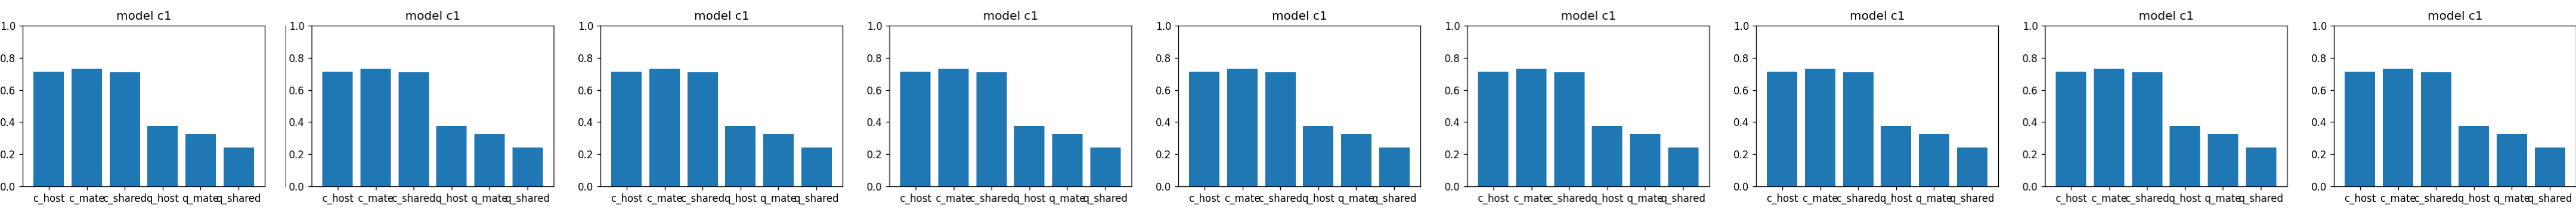

In [31]:
import cv2
import numpy as np
from PIL import Image

def parallax_views(img_path, n_views=9, max_shift=20):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h,w,_ = img.shape
    views=[]
    shifts = np.linspace(-max_shift, max_shift, n_views).astype(np.float32)

    for s in shifts:
        M = np.float32([[1,0,s],[0,1,0]])
        shifted = cv2.warpAffine(img, M, (w,h), borderMode=cv2.BORDER_REFLECT)
        views.append(shifted)
    grid = np.concatenate(views, axis=1)
    return Image.fromarray(grid)

# Show multi-view “holo strip” for a sample
print("Generating parallax view for the first image...")
parallax_views(img_paths[0], n_views=9, max_shift=18)

In [32]:
import cirq
import qsimcirq
import numpy as np

def quantum_features(x_np, n_qubits=8, reps=2):
    """
    x_np: (B, D) -> use first n_qubits features as angles
    returns: (B, 2*n_qubits) expectation features
    """
    B, D = x_np.shape
    qubits = cirq.LineQubit.range(n_qubits)

    simulator = qsimcirq.QSimSimulator()

    feats = []
    for b in range(B):
        angles = x_np[b, :n_qubits]
        circuit = cirq.Circuit()
        # simple encoding
        for i, q in enumerate(qubits):
            circuit.append(cirq.ry(float(angles[i]))(q))
            circuit.append(cirq.rz(float(angles[i]))(q))

        # entangle
        for _ in range(reps):
            for i in range(n_qubits-1):
                circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))

        # measure expectations via statevector
        result = simulator.simulate(circuit)
        state = result.final_state_vector

        # crude “features”: probabilities of |0> on each qubit (from statevector marginals)
        # For small n_qubits this is OK.
        probs = np.abs(state)**2
        # marginal P(q=0)
        q0 = []
        for qi in range(n_qubits):
            mask = 1 << (n_qubits-1-qi)
            p0 = probs[[i for i in range(len(probs)) if (i & mask)==0]].sum()
            q0.append(p0)
        q0 = np.array(q0, dtype=np.float32)
        feats.append(np.concatenate([q0, 1.0-q0], axis=0))
    return np.stack(feats, axis=0)


In [33]:
import json, os

def load_manifest(root):
    items = []
    with open(os.path.join(root, "manifest.jsonl"), "r", encoding="utf-8") as f:
        for line in f:
            j = json.loads(line)
            # Fix paths if they start with /content/...
            def fix(p):
                if p is None: return None
                p = p.replace("/content/synth/", "")
                return os.path.join(root, p) if not os.path.isabs(p) else p
            items.append({
                "text": j.get("text",""),
                "img": fix(j.get("img_path")),
                "aud": fix(j.get("aud_path")),
                "vid": fix(j.get("vid_path")),
            })
    return items

items = load_manifest(root)
items[0]


{'text': '[model] cycle=1 mood=drifting. classical(H=0.714, M=0.733, S=0.709) quantum(H=0.376, M=0.328, S=0.240).',
 'img': None,
 'aud': None,
 'vid': None}

In [34]:
import torch.nn as nn
import torch.nn.functional as F
import random

class Projector(nn.Module):
    def __init__(self, in_dim, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim),
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

def info_nce(a, b, temp=0.07):
    logits = (a @ b.T) / temp
    labels = torch.arange(a.size(0), device=a.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2

# Filter items to only include entries where all modalities are present
# This is necessary because the original manifest contains entries with missing image, audio, or video paths
filtered_items = [
    item for item in items
    if item["img"] is not None and item["aud"] is not None and item["vid"] is not None and item["text"] is not None
]

if not filtered_items:
    print("Warning: No items found with all modalities (text, image, audio, video). Skipping embedding and training.")
else:
    # Extract modalities from filtered items
    texts = [it["text"] for it in filtered_items]
    imgs  = [it["img"]  for it in filtered_items]
    auds  = [it["aud"]  for it in filtered_items]
    vids  = [it["vid"]  for it in filtered_items]

    E_t = embed_text(texts)
    E_i = embed_image(imgs)
    E_a = embed_audio(auds)
    E_v = embed_video(vids)

    proj_t = Projector(E_t.shape[1]).to(torch_device)
    proj_i = Projector(E_i.shape[1]).to(torch_device)
    proj_a = Projector(E_a.shape[1]).to(torch_device)
    proj_v = Projector(E_v.shape[1]).to(torch_device)

    opt = torch.optim.AdamW(
        list(proj_t.parameters())+list(proj_i.parameters())+list(proj_a.parameters())+list(proj_v.parameters()),
        lr=2e-3, weight_decay=1e-4
    )

    N = E_t.size(0)

    for epoch in range(1, 3001):
        idx = torch.randperm(N, device=torch_device)
        # full-batch is fine for N=49
        zt = proj_t(E_t[idx])
        zi = proj_i(E_i[idx])
        za = proj_a(E_a[idx])
        zv = proj_v(E_v[idx])

        loss = (info_nce(zt, zi)+info_nce(zt, za)+info_nce(zt, zv)+
                info_nce(zi, za)+info_nce(zi, zv)+
                info_nce(za, zv))

        opt.zero_grad()
        loss.backward()
        opt.step()

        if epoch % 50 == 0 or epoch == 1:
            print(f"epoch {epoch:4d}  loss {loss.item():.4f}")

In [35]:
!pip -q install brian2 cirq qsimcirq transformers accelerate sentencepiece \
    openai-whisper ffmpeg-python torchaudio soundfile \
    open-clip-torch opencv-python decord pillow

import shutil
if shutil.which("ffmpeg") is None:
    print("ffmpeg not found on OS. Install it:")
    print("Ubuntu: sudo apt-get update && sudo apt-get install -y ffmpeg")
    print("macOS:  brew install ffmpeg")
    print("Win:    choco install ffmpeg")


In [36]:
import os, zipfile, json, numpy as np, pathlib, shutil

ZIP_PATH = "/content/data/synthdata.zip"  # Corrected path
OUT_DIR  = "./data"

# The following lines caused the FileNotFoundError by deleting the zip file before it could be read.
# if os.path.exists(OUT_DIR):
#     shutil.rmtree(OUT_DIR)
os.makedirs(OUT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(OUT_DIR)

ROOT = os.path.join(OUT_DIR, "synthdata", "synth")
manifest_path = os.path.join(ROOT, "manifest.jsonl")

print("ROOT:", ROOT)
print("ROOT contents:", sorted(os.listdir(ROOT)))
print("Manifest:", manifest_path, "exists:", os.path.exists(manifest_path))

items=[]
with open(manifest_path, "r", encoding="utf-8") as f:
    for line in f:
        j=json.loads(line)
        items.append(j)

print("N items:", len(items))
print("Example:", items[0])

ROOT: ./data/synthdata/synth
ROOT contents: ['E_aud.npy', 'E_img.npy', 'E_text.npy', 'E_vid.npy', 'audio', 'haptics', 'images', 'manifest.jsonl', 'text', 'video']
Manifest: ./data/synthdata/synth/manifest.jsonl exists: True
N items: 49
Example: {'i': 0, 'timestamp': '2025-08-17T09:56:43.222236', 'script_name': 'model', 'script_id': 4, 'cycle': 1, 'text': '[model] cycle=1 mood=drifting. classical(H=0.714, M=0.733, S=0.709) quantum(H=0.376, M=0.328, S=0.240).', 'image_path': '/content/synth/images/model_c000001_0000000.png', 'audio_path': '/content/synth/audio/model_c000001_0000000.wav', 'video_path': '/content/synth/video/model_c000001_0000000.mp4'}


In [37]:
def fix_path(p: str) -> str:
    # manifest has /content/synth/images/...
    # your extracted tree is ROOT/images/...
    if p.startswith("/content/synth/"):
        rel = p.replace("/content/synth/", "")
        return os.path.join(ROOT, rel)
    return p

def get_paths(items):
    texts, imgs, auds, vids = [], [], [], []
    for j in items:
        texts.append(j["text"])
        imgs.append(fix_path(j["image_path"]))
        auds.append(fix_path(j["audio_path"]))
        vids.append(fix_path(j["video_path"]))
    return texts, imgs, auds, vids

texts, img_paths, aud_paths, vid_paths = get_paths(items)

print(img_paths[0], os.path.exists(img_paths[0]))
print(aud_paths[0], os.path.exists(aud_paths[0]))
print(vid_paths[0], os.path.exists(vid_paths[0]))


./data/synthdata/synth/images/model_c000001_0000000.png True
./data/synthdata/synth/audio/model_c000001_0000000.wav True
./data/synthdata/synth/video/model_c000001_0000000.mp4 True


In [38]:
import torch
from transformers import AutoTokenizer, AutoModel

torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
whisper_device = "cuda" if torch.cuda.is_available() else "cpu"

TEXT_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
txt_tok = AutoTokenizer.from_pretrained(TEXT_MODEL)
txt_model = AutoModel.from_pretrained(TEXT_MODEL).to(torch_device).eval()

@torch.no_grad()
def embed_text(batch_texts):
    batch = txt_tok(batch_texts, padding=True, truncation=True, return_tensors="pt").to(torch_device)
    out = txt_model(**batch).last_hidden_state  # (B,T,H)
    mask = batch["attention_mask"].unsqueeze(-1)
    pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
    return torch.nn.functional.normalize(pooled, dim=-1)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [39]:
import open_clip
from PIL import Image

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="laion2b_s34b_b79k"
)
clip_model = clip_model.to(torch_device).eval()

@torch.no_grad()
def embed_images(paths):
    ims = [clip_preprocess(Image.open(p).convert("RGB")) for p in paths]
    x = torch.stack(ims).to(torch_device)
    z = clip_model.encode_image(x)
    return torch.nn.functional.normalize(z, dim=-1)


In [40]:
import whisper

wh_model = whisper.load_model("base", device=whisper_device)

@torch.no_grad()
def embed_audio(paths):
    embs = []
    for p in paths:
        audio = whisper.load_audio(p)
        audio = whisper.pad_or_trim(audio)
        mel = whisper.log_mel_spectrogram(audio).to(torch_device)
        enc = wh_model.encoder(mel.unsqueeze(0))   # (1, frames, dim)
        emb = enc.mean(dim=1).squeeze(0)          # (dim,)
        embs.append(emb)
    embs = torch.stack(embs)
    return torch.nn.functional.normalize(embs, dim=-1)


In [41]:
import decord
import torchvision.transforms as T
decord.bridge.set_bridge("torch")

@torch.no_grad()
def embed_video(paths, num_frames=8):
    all_embs = []
    for p in paths:
        vr = decord.VideoReader(p)
        n = len(vr)
        idx = torch.linspace(0, max(n-1, 0), steps=min(num_frames, n)).long()
        frames = vr.get_batch(idx).permute(0,3,1,2)  # (F,C,H,W)
        frames_pil = [T.ToPILImage()(f.cpu()) for f in frames]
        frames_t = torch.stack([clip_preprocess(im) for im in frames_pil]).to(torch_device)
        zf = clip_model.encode_image(frames_t)  # (F,D)
        zv = zf.mean(dim=0)
        all_embs.append(zv)
    all_embs = torch.stack(all_embs)
    return torch.nn.functional.normalize(all_embs, dim=-1)


In [42]:
from transformers import pipeline

sent_pipe = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", device=0 if device=="cuda" else -1)

def sentiment_scores(texts):
    # returns float in [0,1] where 1=positive
    outs = sent_pipe(texts, truncation=True)
    scores = []
    for o in outs:
        if o["label"].upper().startswith("POS"):
            scores.append(float(o["score"]))
        else:
            scores.append(1.0 - float(o["score"]))
    return np.array(scores, dtype=np.float32)

s_scores = sentiment_scores(texts)
s_scores[:5], s_scores.mean()


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

(array([0.00513488, 0.00370187, 0.00497109, 0.00513488, 0.00445032],
       dtype=float32),
 np.float32(0.25469378))

In [43]:
import torch
import soundfile as sf
import numpy as np

HAPT_DIR = os.path.join(ROOT, "haptics")
os.makedirs(HAPT_DIR, exist_ok=True)

def gen_haptics_for_audio(wav_path, sentiment, T=200):
    audio, sr = sf.read(wav_path, dtype="float32", always_2d=True)
    wav = torch.tensor(audio).T  # (ch,n)  # (ch, n)
    wav = wav.mean(dim=0)                # mono
    # energy envelope
    hop = max(1, wav.shape[0] // T)
    env = []
    for i in range(T):
        seg = wav[i*hop:(i+1)*hop]
        env.append(seg.abs().mean().item() if seg.numel() else 0.0)
    env = np.array(env, dtype=np.float32)
    env = (env - env.min()) / (env.max() - env.min() + 1e-8)

    # sentiment modulates "smoothness" and intensity
    vib = np.clip(0.2 + 0.8*(0.6*env + 0.4*sentiment), 0, 1)

    # pulse proxy: more pulses if negative/tense (1-sentiment)
    pulse = np.clip((1.0 - sentiment) * (0.3 + 0.7*env), 0, 1)

    # pressure proxy: stable “force” tied to env but biased by sentiment
    force = np.clip(0.1 + 0.9*(0.7*env + 0.3*sentiment), 0, 1)

    return np.stack([vib, pulse, force], axis=1).astype(np.float32)

hapt_paths = []
for j, wav_path, s in zip(items, aud_paths, s_scores):
    hp = os.path.join(HAPT_DIR, f"{j['i']:04d}.npy")
    np.save(hp, gen_haptics_for_audio(wav_path, float(s), T=200))
    hapt_paths.append(hp)

print("Saved haptics:", hapt_paths[0], np.load(hapt_paths[0]).shape)


Saved haptics: ./data/synthdata/synth/haptics/0000.npy (200, 3)


In [44]:
!apt-get update -qq && apt-get install -qq -y ffmpeg

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [45]:
import torch
!pip install torchcodec
import soundfile as sf
import numpy as np

HAPT_DIR = os.path.join(ROOT, "haptics")
os.makedirs(HAPT_DIR, exist_ok=True)

def gen_haptics_for_audio(wav_path, sentiment, T=200):
    audio, sr = sf.read(wav_path, dtype="float32", always_2d=True)
    wav = torch.tensor(audio).T  # (ch,n)  # (ch, n)
    wav = wav.mean(dim=0)                # mono
    # energy envelope
    hop = max(1, wav.shape[0] // T)
    env = []
    for i in range(T):
        seg = wav[i*hop:(i+1)*hop]
        env.append(seg.abs().mean().item() if seg.numel() else 0.0)
    env = np.array(env, dtype=np.float32)
    env = (env - env.min()) / (env.max() - env.min() + 1e-8)

    # sentiment modulates "smoothness" and intensity
    vib = np.clip(0.2 + 0.8*(0.6*env + 0.4*sentiment), 0, 1)

    # pulse proxy: more pulses if negative/tense (1-sentiment)
    pulse = np.clip((1.0 - sentiment) * (0.3 + 0.7*env), 0, 1)

    # pressure proxy: stable “force” tied to env but biased by sentiment
    force = np.clip(0.1 + 0.9*(0.7*env + 0.3*sentiment), 0, 1)

    return np.stack([vib, pulse, force], axis=1).astype(np.float32)

hapt_paths = []
for j, wav_path, s in zip(items, aud_paths, s_scores):
    hp = os.path.join(HAPT_DIR, f"{j['i']:04d}.npy")
    np.save(hp, gen_haptics_for_audio(wav_path, float(s), T=200))
    hapt_paths.append(hp)

print("Saved haptics:", hapt_paths[0], np.load(hapt_paths[0]).shape)


Saved haptics: ./data/synthdata/synth/haptics/0000.npy (200, 3)


In [46]:
import torch.nn as nn
import torch.nn.functional as F

class HapticsEncoder(nn.Module):
    def __init__(self, in_ch=3, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.proj = nn.Linear(64, out_dim)

    def forward(self, x):  # x: (B,T,C)
        x = x.transpose(1,2)        # (B,C,T)
        h = self.net(x).squeeze(-1) # (B,64)
        z = self.proj(h)
        return F.normalize(z, dim=-1)

def load_haptics_batch(paths):
    arr = [np.load(p) for p in paths]  # each (T,3)
    x = torch.tensor(np.stack(arr, axis=0), dtype=torch.float32, device=torch_device)
    return x


In [47]:
from brian2 import *
import numpy as np

def brian2_rate_features(x_np, sim_ms=30.0):
    """
    x_np: (B, D) float32
    returns: (B, D) spike rates
    """
    B, D = x_np.shape
    x = x_np
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)

    defaultclock.dt = 0.1*ms
    tau = 10*ms
    eqs = '''
    dv/dt = (-v + I)/tau : 1
    I : 1
    '''

    rates_out = []
    for b in range(B):
        G = NeuronGroup(D, eqs, threshold='v>1', reset='v=0', method='euler')
        G.I = x[b]
        M = SpikeMonitor(G)
        run(sim_ms*ms)
        rate = np.array(M.count) / (sim_ms/1000.0)
        rates_out.append(rate.astype(np.float32))
        device.reinit(); device.activate()
    return np.stack(rates_out, axis=0)

# Example: make spiking features from text embeddings (first 128 dims for speed)


In [48]:
import cirq, qsimcirq
import numpy as np

def quantum_features(x_np, n_qubits=8, reps=2):
    B, D = x_np.shape
    qubits = cirq.LineQubit.range(n_qubits)
    sim = qsimcirq.QSimSimulator()

    feats=[]
    for b in range(B):
        angles = x_np[b, :n_qubits]
        c = cirq.Circuit()
        for i,q in enumerate(qubits):
            c.append(cirq.ry(float(angles[i]))(q))
            c.append(cirq.rz(float(angles[i]))(q))
        for _ in range(reps):
            for i in range(n_qubits-1):
                c.append(cirq.CNOT(qubits[i], qubits[i+1]))
        r = sim.simulate(c)
        state = r.final_state_vector
        probs = np.abs(state)**2

        q0=[]
        for qi in range(n_qubits):
            mask = 1 << (n_qubits-1-qi)
            p0 = probs[[i for i in range(len(probs)) if (i & mask)==0]].sum()
            q0.append(p0)
        q0 = np.array(q0, dtype=np.float32)
        feats.append(np.concatenate([q0, 1.0-q0], axis=0))
    return np.stack(feats, axis=0)


In [49]:
import torch
!pip install torchcodec
import soundfile as sf
import numpy as np

HAPT_DIR = os.path.join(ROOT, "haptics")
os.makedirs(HAPT_DIR, exist_ok=True)

def gen_haptics_for_audio(wav_path, sentiment, T=200):
    audio, sr = sf.read(wav_path, dtype="float32", always_2d=True)
    wav = torch.tensor(audio).T  # (ch,n)  # (ch, n)
    wav = wav.mean(dim=0)                # mono
    # energy envelope
    hop = max(1, wav.shape[0] // T)
    env = []
    for i in range(T):
        seg = wav[i*hop:(i+1)*hop]
        env.append(seg.abs().mean().item() if seg.numel() else 0.0)
    env = np.array(env, dtype=np.float32)
    env = (env - env.min()) / (env.max() - env.min() + 1e-8)

    # sentiment modulates "smoothness" and intensity
    vib = np.clip(0.2 + 0.8*(0.6*env + 0.4*sentiment), 0, 1)

    # pulse proxy: more pulses if negative/tense (1-sentiment)
    pulse = np.clip((1.0 - sentiment) * (0.3 + 0.7*env), 0, 1)

    # pressure proxy: stable “force” tied to env but biased by sentiment
    force = np.clip(0.1 + 0.9*(0.7*env + 0.3*sentiment), 0, 1)

    return np.stack([vib, pulse, force], axis=1).astype(np.float32)

hapt_paths = []
for j, wav_path, s in zip(items, aud_paths, s_scores):
    hp = os.path.join(HAPT_DIR, f"{j['i']:04d}.npy")
    np.save(hp, gen_haptics_for_audio(wav_path, float(s), T=200))
    hapt_paths.append(hp)

print("Saved haptics:", hapt_paths[0], np.load(hapt_paths[0]).shape)


Saved haptics: ./data/synthdata/synth/haptics/0000.npy (200, 3)


In [50]:
!ffmpeg -version

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-l

In [51]:
from brian2 import *
import numpy as np

def brian2_rate_features(x_np, sim_ms=30.0):
    """
    x_np: (B, D) float32
    returns: (B, D) spike rates
    """
    B, D = x_np.shape
    x = x_np
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)

    defaultclock.dt = 0.1*ms
    tau = 10*ms
    eqs = '''
    dv/dt = (-v + I)/tau : 1
    I : 1
    '''

    rates_out = []
    for b in range(B):
        G = NeuronGroup(D, eqs, threshold='v>1', reset='v=0', method='euler')
        G.I = x[b]
        M = SpikeMonitor(G)
        run(sim_ms*ms)
        rate = np.array(M.count) / (sim_ms/1000.0)
        rates_out.append(rate.astype(np.float32))
        device.reinit(); device.activate()
    return np.stack(rates_out, axis=0)

# Example: make spiking features from text embeddings (first 128 dims for speed)


In [52]:
import cirq, qsimcirq
import numpy as np

def quantum_features(x_np, n_qubits=8, reps=2):
    B, D = x_np.shape
    qubits = cirq.LineQubit.range(n_qubits)
    sim = qsimcirq.QSimSimulator()

    feats=[]
    for b in range(B):
        angles = x_np[b, :n_qubits]
        c = cirq.Circuit()
        for i,q in enumerate(qubits):
            c.append(cirq.ry(float(angles[i]))(q))
            c.append(cirq.rz(float(angles[i]))(q))
        for _ in range(reps):
            for i in range(n_qubits-1):
                c.append(cirq.CNOT(qubits[i], qubits[i+1]))
        r = sim.simulate(c)
        state = r.final_state_vector
        probs = np.abs(state)**2

        q0=[]
        for qi in range(n_qubits):
            mask = 1 << (n_qubits-1-qi)
            p0 = probs[[i for i in range(len(probs)) if (i & mask)==0]].sum()
            q0.append(p0)
        q0 = np.array(q0, dtype=np.float32)
        feats.append(np.concatenate([q0, 1.0-q0], axis=0))
    return np.stack(feats, axis=0)


In [53]:
import torch

E_t = embed_text(texts)
E_i = embed_images(img_paths)
E_a = embed_audio(aud_paths)
E_v = embed_video(vid_paths)

print(E_t.shape, E_i.shape, E_a.shape, E_v.shape)


torch.Size([49, 384]) torch.Size([49, 512]) torch.Size([49, 512]) torch.Size([49, 512])


In [54]:
import numpy as np

# --- Text synaptic+quantum augmentation (fast enough for N=49) ---
E_t_np = E_t.detach().cpu().numpy().astype(np.float32)

S_t = brian2_rate_features(E_t_np[:, :128], sim_ms=25.0)      # synaptic features
Q_t = quantum_features(E_t_np[:, :8], n_qubits=8, reps=2)     # quantum features

E_t_aug = torch.tensor(np.concatenate([E_t_np, S_t, Q_t], axis=1), device=torch_device, dtype=torch.float32)
E_t_aug = torch.nn.functional.normalize(E_t_aug, dim=-1)

print("E_t_aug:", E_t_aug.shape)


E_t_aug: torch.Size([49, 528])


In [55]:
import torch.nn as nn
import torch.nn.functional as F

class Projector(nn.Module):
    def __init__(self, in_dim, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim),
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

def info_nce(a, b, temp=0.07):
    logits = (a @ b.T) / temp
    labels = torch.arange(a.size(0), device=a.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2

h_enc = HapticsEncoder(in_ch=3, out_dim=256).to(torch_device)

p_t = Projector(E_t_aug.shape[1]).to(torch_device)
p_i = Projector(E_i.shape[1]).to(torch_device)
p_a = Projector(E_a.shape[1]).to(torch_device)
p_v = Projector(E_v.shape[1]).to(torch_device)

opt = torch.optim.AdamW(
    list(h_enc.parameters()) + list(p_t.parameters()) + list(p_i.parameters()) +
    list(p_a.parameters()) + list(p_v.parameters()),
    lr=2e-3, weight_decay=1e-4
)

H = load_haptics_batch(hapt_paths)      # (N,T,3)
N = E_i.shape[0]

for epoch in range(1, 4001):
    idx = torch.randperm(N, device=torch_device)

    zt = p_t(E_t_aug[idx])
    zi = p_i(E_i[idx])
    za = p_a(E_a[idx])
    zv = p_v(E_v[idx])
    zh = h_enc(H[idx])

    # all-pairs contrastive (5 modalities)
    loss = (
        info_nce(zt, zi) + info_nce(zt, za) + info_nce(zt, zv) + info_nce(zt, zh) +
        info_nce(zi, za) + info_nce(zi, zv) + info_nce(zi, zh) +
        info_nce(za, zv) + info_nce(za, zh) +
        info_nce(zv, zh)
    )

    opt.zero_grad()
    loss.backward()
    opt.step()

    if epoch % 50 == 0 or epoch == 1:
        print(f"epoch {epoch:4d}  loss {loss.item():.4f}")


epoch    1  loss 38.9517
epoch   50  loss 27.7134
epoch  100  loss 23.0589
epoch  150  loss 17.8740
epoch  200  loss 14.5581
epoch  250  loss 14.9424
epoch  300  loss 12.1037
epoch  350  loss 11.9568
epoch  400  loss 11.8163
epoch  450  loss 11.7576
epoch  500  loss 11.7148
epoch  550  loss 11.7536
epoch  600  loss 11.7043
epoch  650  loss 11.6873
epoch  700  loss 11.7057
epoch  750  loss 27.1833
epoch  800  loss 13.2788
epoch  850  loss 11.9157
epoch  900  loss 11.7343
epoch  950  loss 11.7207
epoch 1000  loss 11.7705
epoch 1050  loss 11.7106
epoch 1100  loss 11.6624
epoch 1150  loss 11.6425
epoch 1200  loss 11.6691
epoch 1250  loss 11.6491
epoch 1300  loss 11.6423
epoch 1350  loss 11.8227
epoch 1400  loss 11.6627
epoch 1450  loss 11.6131
epoch 1500  loss 11.6307
epoch 1550  loss 11.6207
epoch 1600  loss 11.6702
epoch 1650  loss 11.6219
epoch 1700  loss 11.6453
epoch 1750  loss 11.6261
epoch 1800  loss 11.6140
epoch 1850  loss 11.6003
epoch 1900  loss 11.6220
epoch 1950  loss 11.6602


In [56]:
@torch.no_grad()
def retrieve_text_to_video(query_text, topk=5):
    q = embed_text([query_text])
    # augment query in same way:
    q_np = q.detach().cpu().numpy().astype(np.float32)
    S_q = brian2_rate_features(q_np[:, :128], sim_ms=25.0)
    Q_q = quantum_features(q_np[:, :8], n_qubits=8, reps=2)
    q_aug = torch.tensor(np.concatenate([q_np, S_q, Q_q], axis=1), device=torch_device, dtype=torch.float32)
    q_aug = torch.nn.functional.normalize(q_aug, dim=-1)

    zq = p_t(q_aug)                # (1,256)
    zv_all = p_v(E_v)              # (N,256)
    sims = (zq @ zv_all.T).squeeze(0)
    vals, inds = torch.topk(sims, k=min(topk, len(sims)))
    return [(int(i.item()), float(v.item()), vid_paths[int(i.item())]) for v,i in zip(vals, inds)]

retrieve_text_to_video("drifting mood model cycle", topk=5)


[(2,
  0.7658683061599731,
  './data/synthdata/synth/video/client_c000001_0000002.mp4'),
 (13,
  0.7658683061599731,
  './data/synthdata/synth/video/client_c000001_0000013.mp4'),
 (15,
  0.7658683061599731,
  './data/synthdata/synth/video/client_c000002_0000015.mp4'),
 (14,
  0.7658683061599731,
  './data/synthdata/synth/video/client_c000002_0000014.mp4'),
 (8,
  0.474947988986969,
  './data/synthdata/synth/video/cookie_c000001_0000008.mp4')]

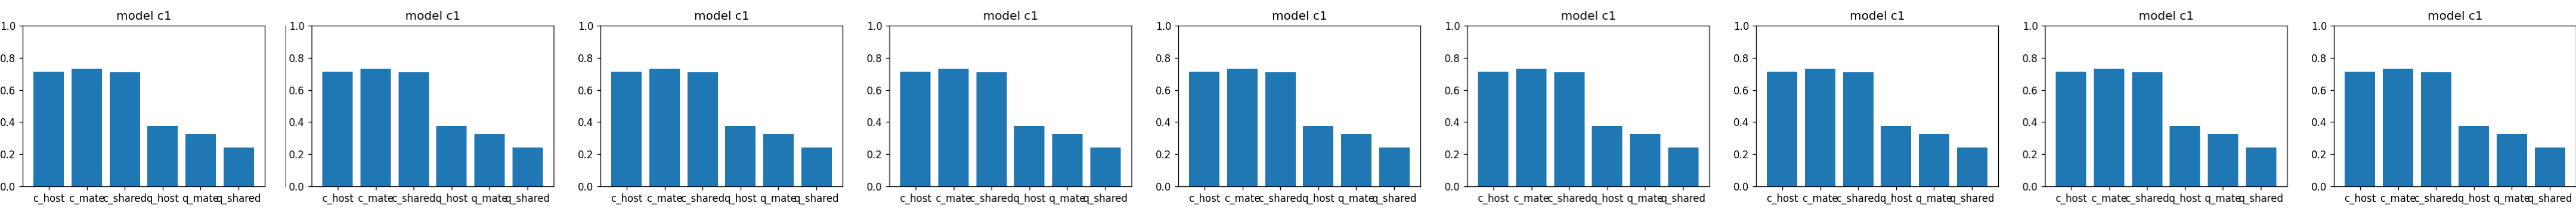

In [57]:
import cv2
import numpy as np
from PIL import Image

def parallax_views(img_path, n_views=9, max_shift=20):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h,w,_ = img.shape
    views=[]
    shifts = np.linspace(-max_shift, max_shift, n_views).astype(np.float32)

    for s in shifts:
        M = np.float32([[1,0,s],[0,1,0]])
        shifted = cv2.warpAffine(img, M, (w,h), borderMode=cv2.BORDER_REFLECT)
        views.append(shifted)
    grid = np.concatenate(views, axis=1)
    return Image.fromarray(grid)

# Show multi-view “holo strip” for a sample
parallax_views(img_paths[0], n_views=9, max_shift=18)


In [58]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HoloSynHeads(nn.Module):
    def __init__(self, p_t, p_i, p_a, p_v, h_enc):
        super().__init__()
        self.p_t = p_t
        self.p_i = p_i
        self.p_a = p_a
        self.p_v = p_v
        self.h_enc = h_enc

    def forward(self, E_t_aug, E_i, E_a, E_v, H):
        # Returns shared-space embeddings (all normalized)
        zt = self.p_t(E_t_aug)
        zi = self.p_i(E_i)
        za = self.p_a(E_a)
        zv = self.p_v(E_v)
        zh = self.h_enc(H)
        return zt, zi, za, zv, zh


In [59]:
bundle = HoloSynHeads(p_t, p_i, p_a, p_v, h_enc).to(torch_device).eval()

torch.save(
    {
        "state_dict": bundle.state_dict(),
        "dims": {
            "E_t_aug": E_t_aug.shape[1],
            "E_i": E_i.shape[1],
            "E_a": E_a.shape[1],
            "E_v": E_v.shape[1],
            "H_T": H.shape[1],
            "H_C": H.shape[2],
        },
    },
    "holosyn_heads.pt"
)
print("Saved holosyn_heads.pt")

Saved holosyn_heads.pt


In [60]:
compiled_bundle = torch.compile(bundle, mode="max-autotune")  # or mode="reduce-overhead"
compiled_bundle = compiled_bundle.eval()

# sanity forward
with torch.no_grad():
    zt, zi, za, zv, zh = compiled_bundle(E_t_aug, E_i, E_a, E_v, H)
print("Compiled forward OK:", zt.shape, zh.shape)


WARNING    /usr/local/lib/python3.12/dist-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()
 [py.warnings]
  return _C._get_float32_matmul_precision()

Autotune Choices Stats:
{"num_choices": 2, "num_triton_choices": 0, "best_kernel": "addmm", "best_time": 2.7049415000419685}
AUTOTUNE addmm(49x512, 49x528, 528x512)
strides: [0, 1], [528, 1], [1, 528]
dtypes: torch.float32, torch.float32, torch.float32
  addmm 2.7049 ms 100.0% 
  bias

Compiled forward OK: torch.Size([49, 256]) torch.Size([49, 256])


In [61]:
compiled_bundle = torch.compile(bundle, mode="max-autotune")  # or mode="reduce-overhead"
compiled_bundle = compiled_bundle.eval()

# sanity forward
with torch.no_grad():
    zt, zi, za, zv, zh = compiled_bundle(E_t_aug, E_i, E_a, E_v, H)
print("Compiled forward OK:", zt.shape, zh.shape)

Compiled forward OK: torch.Size([49, 256]) torch.Size([49, 256])


In [62]:
compiled_bundle = torch.compile(bundle, mode="reduce-overhead")


In [63]:
example_inputs = (E_t_aug[:1], E_i[:1], E_a[:1], E_v[:1], H[:1])
ts = torch.jit.trace(bundle, example_inputs)
ts.save("holosyn_heads.torchscript.pt")
print("Saved holosyn_heads.torchscript.pt")


Saved holosyn_heads.torchscript.pt


In [64]:
example_inputs = (E_t_aug[:1], E_i[:1], E_a[:1], E_v[:1], H[:1])
ts = torch.jit.trace(bundle, example_inputs)
ts.save("holosyn_heads.torchscript.pt")
print("Saved holosyn_heads.torchscript.pt")


Saved holosyn_heads.torchscript.pt


In [65]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HoloSynHeads(nn.Module):
    def __init__(self, p_t, p_i, p_a, p_v, h_enc):
        super().__init__()
        self.p_t = p_t
        self.p_i = p_i
        self.p_a = p_a
        self.p_v = p_v
        self.h_enc = h_enc

    def forward(self, E_t_aug, E_i, E_a, E_v, H):
        zt = self.p_t(E_t_aug)
        zi = self.p_i(E_i)
        za = self.p_a(E_a)
        zv = self.p_v(E_v)
        zh = self.h_enc(H)
        return zt, zi, za, zv, zh

heads = HoloSynHeads(p_t, p_i, p_a, p_v, h_enc).to(torch_device).eval()

# optional compile (heads only; stable)
heads = torch.compile(heads, mode="reduce-overhead")


In [66]:
import numpy as np
import torch
import torch.nn.functional as F
import soundfile as sf

class HoloSynInfer:
    def __init__(
        self,
        heads,
        embed_text_fn,
        embed_image_fn,
        embed_audio_fn,
        embed_video_fn,
        torch_device,
        # optional: synaptic + quantum augmenters (can be None)
        synaptic_fn=None,   # brian2_rate_features
        quantum_fn=None,    # quantum_features
        syn_sim_ms=25.0,
        q_n_qubits=8,
        q_reps=2,
        # synthetic haptics generator (callable)
        synth_haptics_fn=None
    ):
        self.heads = heads.eval()
        self.embed_text = embed_text_fn
        self.embed_image = embed_image_fn
        self.embed_audio = embed_audio_fn
        self.embed_video = embed_video_fn
        self.torch_device = torch_device

        self.synaptic_fn = synaptic_fn
        self.quantum_fn = quantum_fn
        self.syn_sim_ms = syn_sim_ms
        self.q_n_qubits = q_n_qubits
        self.q_reps = q_reps

        self.synth_haptics_fn = synth_haptics_fn

    def _augment_text(self, E_t: torch.Tensor) -> torch.Tensor:
        """
        E_t: (1, D) torch tensor
        returns E_t_aug: (1, D + syn + q) torch tensor
        If synaptic_fn/quantum_fn are None -> returns E_t unchanged.
        """
        if (self.synaptic_fn is None) and (self.quantum_fn is None):
            return E_t

        E_np = E_t.detach().cpu().numpy().astype(np.float32)
        parts = [E_np]

        if self.synaptic_fn is not None:
            # use first 128 dims for speed (adjust if you want)
            S = self.synaptic_fn(E_np[:, :128], sim_ms=self.syn_sim_ms)
            parts.append(S)

        if self.quantum_fn is not None:
            Q = self.quantum_fn(E_np[:, :8], n_qubits=self.q_n_qubits, reps=self.q_reps)
            parts.append(Q)

        E_aug = np.concatenate(parts, axis=1).astype(np.float32)
        E_aug = torch.tensor(E_aug, device=self.torch_device)
        return F.normalize(E_aug, dim=-1)

    def _haptics_to_tensor(self, haptics_np: np.ndarray) -> torch.Tensor:
        """
        haptics_np: (T, C) float32
        returns: (1, T, C) torch tensor
        """
        if haptics_np.ndim != 2:
            raise ValueError("haptics_np must be (T, C)")
        return torch.tensor(haptics_np[None, ...], dtype=torch.float32, device=self.torch_device)

    @torch.no_grad()
    def infer(
        self,
        text: str | None = None,
        image_path: str | None = None,
        audio_path: str | None = None,
        video_path: str | None = None,
        haptics_np: np.ndarray | None = None,
        force_synth_haptics: bool = False,
        synth_T: int = 200
    ):
        """
        Returns dict with:
          - zt, zi, za, zv, zh (each (1,256) depending on your heads)
          - plus raw modality embeddings E_* (useful for debugging)
        """
        # --- Text ---
        if text is None:
            text = ""
        E_t = self.embed_text([text])                  # (1, Dt)
        E_t = E_t.to(self.torch_device)
        E_t_aug = self._augment_text(E_t)             # (1, Dt_aug)

        # --- Image ---
        if image_path is None:
            # dummy zero vector if missing (keeps pipeline stable)
            E_i = torch.zeros((1, self.heads.p_i.net[0].in_features), device=self.torch_device)
        else:
            E_i = self.embed_image([image_path])      # (1, Di)
            E_i = E_i.to(self.torch_device)

        # --- Audio ---
        if audio_path is None:
            E_a = torch.zeros((1, self.heads.p_a.net[0].in_features), device=self.torch_device)
        else:
            E_a = self.embed_audio([audio_path])      # (1, Da)
            E_a = E_a.to(self.torch_device)

        # --- Video ---
        if video_path is None:
            E_v = torch.zeros((1, self.heads.p_v.net[0].in_features), device=self.torch_device)
        else:
            E_v = self.embed_video([video_path])      # (1, Dv)
            E_v = E_v.to(self.torch_device)

        # --- Haptics (real or synthetic) ---
        if (haptics_np is None) or force_synth_haptics:
            if self.synth_haptics_fn is None:
                # default: zeros if no generator provided
                H = torch.zeros((1, synth_T, 3), device=self.torch_device)
            else:
                # if audio exists, drive haptics from audio energy; else from text only
                H_np = self.synth_haptics_fn(audio_path=audio_path, text=text, T=synth_T)
                H = self._haptics_to_tensor(H_np)
        else:
            H = self._haptics_to_tensor(haptics_np)

        # --- Heads (shared space) ---
        zt, zi, za, zv, zh = self.heads(E_t_aug, E_i, E_a, E_v, H)

        return {
            "zt": zt, "zi": zi, "za": za, "zv": zv, "zh": zh,
            "E_t": E_t, "E_t_aug": E_t_aug, "E_i": E_i, "E_a": E_a, "E_v": E_v, "H": H
        }


In [67]:
import numpy as np
import soundfile as sf

def synth_haptics(audio_path: str | None, text: str, T: int = 200) -> np.ndarray:
    # channels: vib, pulse, force in [0,1]
    if audio_path is not None:
        audio, sr = sf.read(audio_path, dtype="float32", always_2d=True)
        wav = audio.mean(axis=1)  # (n,)
        hop = max(1, len(wav) // T)
        env = np.array([np.mean(np.abs(wav[i*hop:(i+1)*hop])) if (i*hop) < len(wav) else 0.0 for i in range(T)],
                       dtype=np.float32)
        env = (env - env.min()) / (env.max() - env.min() + 1e-8)
    else:
        # deterministic pseudo-envelope from text
        seed = (hash(text) % 10_000_000)
        rng = np.random.default_rng(seed)
        env = rng.random(T, dtype=np.float32)

    # simple “sentiment proxy”: more positive if more exclamation marks / happy tokens
    pos_hint = float(text.count("!") + text.lower().count("good") + text.lower().count("love"))
    sent = 1.0 / (1.0 + np.exp(-(pos_hint - 1.0)))  # squashed to (0,1)

    vib   = np.clip(0.15 + 0.85*(0.65*env + 0.35*sent), 0, 1)
    pulse = np.clip((1.0 - sent) * (0.25 + 0.75*env), 0, 1)
    force = np.clip(0.10 + 0.90*(0.75*env + 0.25*sent), 0, 1)

    return np.stack([vib, pulse, force], axis=1).astype(np.float32)


In [68]:
infer = HoloSynInfer(
    heads=heads,
    embed_text_fn=embed_text,
    embed_image_fn=embed_images,
    embed_audio_fn=lambda ps: embed_audio(ps),   # your whisper embedding fn
    embed_video_fn=lambda ps: embed_video(ps),   # your video embedding fn
    torch_device=torch_device,
    synaptic_fn=brian2_rate_features,   # or None for faster inference
    quantum_fn=quantum_features,        # or None for faster inference
    synth_haptics_fn=synth_haptics
)

out = infer.infer(
    text="a calm drifting mood",
    image_path=img_paths[0],
    audio_path=aud_paths[0],
    video_path=vid_paths[0],
    haptics_np=None,              # None -> synthetic
    force_synth_haptics=True
)

out["zt"].shape, out["zh"].shape


cudagraph partition due to non gpu ops. Found from : 
   File "/tmp/ipython-input-501203991.py", line 15, in forward
    zt = self.p_t(E_t_aug)
  File "/tmp/ipython-input-1550232592.py", line 13, in forward
    return F.normalize(self.net(x), dim=-1)

cudagraph partition due to non gpu ops. Found from : 
   File "/tmp/ipython-input-501203991.py", line 16, in forward
    zi = self.p_i(E_i)
  File "/tmp/ipython-input-1550232592.py", line 13, in forward
    return F.normalize(self.net(x), dim=-1)

cudagraph partition due to non gpu ops. Found from : 
   File "/tmp/ipython-input-501203991.py", line 17, in forward
    za = self.p_a(E_a)
  File "/tmp/ipython-input-1550232592.py", line 13, in forward
    return F.normalize(self.net(x), dim=-1)

cudagraph partition due to non gpu ops. Found from : 
   File "/tmp/ipython-input-501203991.py", line 18, in forward
    zv = self.p_v(E_v)
  File "/tmp/ipython-input-1550232592.py", line 13, in forward
    return F.normalize(self.net(x), dim=-1)

cuda

(torch.Size([1, 256]), torch.Size([1, 256]))

In [69]:
@torch.no_grad()
def cosine_sim(a, b):
    a = F.normalize(a, dim=-1); b = F.normalize(b, dim=-1)
    return (a @ b.T)

# similarity between text and video embedding in shared space
sim_tv = cosine_sim(out["zt"], out["zv"]).item()
sim_ti = cosine_sim(out["zt"], out["zi"]).item()
sim_ta = cosine_sim(out["zt"], out["za"]).item()
sim_th = cosine_sim(out["zt"], out["zh"]).item()

(sim_tv, sim_ti, sim_ta, sim_th)


(-0.3237665295600891,
 -0.15424653887748718,
 -0.012025050818920135,
 0.1592712700366974)

In [70]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ZFuse(nn.Module):
    """
    Fuses modality embeddings into a single latent Z by weighted average.
    You can learn these weights later; for now, keep them simple.
    """
    def __init__(self, d=256):
        super().__init__()
        self.logits = nn.Parameter(torch.zeros(5))  # t,i,a,v,h weights (learnable)

    def forward(self, zt=None, zi=None, za=None, zv=None, zh=None):
        zs = []
        ws = []
        weights = torch.softmax(self.logits, dim=0)  # (5,)
        # order: t,i,a,v,h
        if zt is not None: zs.append(zt); ws.append(weights[0])
        if zi is not None: zs.append(zi); ws.append(weights[1])
        if za is not None: zs.append(za); ws.append(weights[2])
        if zv is not None: zs.append(zv); ws.append(weights[3])
        if zh is not None: zs.append(zh); ws.append(weights[4])

        if len(zs) == 0:
            raise ValueError("No modalities provided to fuse.")

        Z = 0.0
        wsum = 0.0
        for z, w in zip(zs, ws):
            Z = Z + w * z
            wsum = wsum + w
        Z = Z / (wsum + 1e-8)
        return F.normalize(Z, dim=-1)

class HapticsDecoder(nn.Module):
    """
    Decode a shared latent Z -> haptic command sequence (T,3).
    Output channels: [vibration, pulse, force] in [0,1].
    """
    def __init__(self, z_dim=256, hidden=256, out_ch=3):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(z_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.out = nn.Linear(hidden, out_ch)

    def forward(self, Z, T=200):
        # Z: (B, z_dim)
        h = self.fc(Z)              # (B, hidden)
        # replicate over time
        hT = h.unsqueeze(1).repeat(1, T, 1)  # (B,T,hidden)
        y = torch.sigmoid(self.out(hT))      # (B,T,3)
        return y


In [71]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ZFuse(nn.Module):
    """
    Fuses modality embeddings into a single latent Z by weighted average.
    You can learn these weights later; for now, keep them simple.
    """
    def __init__(self, d=256):
        super().__init__()
        self.logits = nn.Parameter(torch.zeros(5))  # t,i,a,v,h weights (learnable)

    def forward(self, zt=None, zi=None, za=None, zv=None, zh=None):
        zs = []
        ws = []
        weights = torch.softmax(self.logits, dim=0)  # (5,)
        # order: t,i,a,v,h
        if zt is not None: zs.append(zt); ws.append(weights[0])
        if zi is not None: zs.append(zi); ws.append(weights[1])
        if za is not None: zs.append(za); ws.append(weights[2])
        if zv is not None: zs.append(zv); ws.append(weights[3])
        if zh is not None: zs.append(zh); ws.append(weights[4])

        if len(zs) == 0:
            raise ValueError("No modalities provided to fuse.")

        Z = 0.0
        wsum = 0.0
        for z, w in zip(zs, ws):
            Z = Z + w * z
            wsum = wsum + w
        Z = Z / (wsum + 1e-8)
        return F.normalize(Z, dim=-1)

class HapticsDecoder(nn.Module):
    """
    Decode a shared latent Z -> haptic command sequence (T,3).
    Output channels: [vibration, pulse, force] in [0,1].
    """
    def __init__(self, z_dim=256, hidden=256, out_ch=3):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(z_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.out = nn.Linear(hidden, out_ch)

    def forward(self, Z, T=200):
        # Z: (B, z_dim)
        h = self.fc(Z)              # (B, hidden)
        # replicate over time
        hT = h.unsqueeze(1).repeat(1, T, 1)  # (B,T,hidden)
        y = torch.sigmoid(self.out(hT))      # (B,T,3)
        return y


In [72]:
fuse = ZFuse(d=256).to(torch_device).eval()
hdec = HapticsDecoder(z_dim=256).to(torch_device).eval()

# optional compile these too:
fuse = torch.compile(fuse, mode="reduce-overhead")
hdec = torch.compile(hdec, mode="reduce-overhead")

infer = HoloSynInfer(
    heads=heads,
    embed_text_fn=embed_text,
    embed_image_fn=embed_images,
    embed_audio_fn=lambda ps: embed_audio(ps),
    embed_video_fn=lambda ps: embed_video(ps),
    torch_device=torch_device,
    synaptic_fn=brian2_rate_features,   # set None for faster inference
    quantum_fn=quantum_features,        # set None for faster inference
    synth_haptics_fn=synth_haptics
)

In [73]:
out = infer.infer(
    text="tense mood, accelerating energy",
    image_path=img_paths[0],
    audio_path=aud_paths[0],
    video_path=vid_paths[0],
    haptics_np=None,
    force_synth_haptics=True,
    synth_T=200
)

# Perform fusion and decoding here
Z_fused = fuse(zt=out["zt"], zi=out["zi"], za=out["za"], zv=out["zv"], zh=out["zh"])
H_out = hdec(Z_fused, T=200)

out["Z_fused"] = Z_fused
out["H_out"] = H_out

print("Z_fused:", out["Z_fused"].shape)
print("H_out:", out["H_out"].shape)  # (1,200,3)

cudagraph partition due to non gpu ops. Found from : 
   File "/tmp/ipython-input-1620960895.py", line 17, in forward
    weights = torch.softmax(self.logits, dim=0)  # (5,)

cudagraph partition due to non gpu ops. Found from : 
   File "/tmp/ipython-input-1620960895.py", line 33, in forward
    Z = Z / (wsum + 1e-8)

cudagraph partition due to non gpu ops. Found from : 
   File "/tmp/ipython-input-1620960895.py", line 34, in forward
    return F.normalize(Z, dim=-1)

cudagraph partition due to non gpu ops. Found from : 
   File "/tmp/ipython-input-1620960895.py", line 34, in forward
    return F.normalize(Z, dim=-1)

cudagraph partition due to non gpu ops. Found from : 
   File "/tmp/ipython-input-1620960895.py", line 53, in forward
    h = self.fc(Z)              # (B, hidden)

cudagraph partition due to non gpu ops. Found from : 
   File "/tmp/ipython-input-1620960895.py", line 53, in forward
    h = self.fc(Z)              # (B, hidden)

cudagraph partition due to non gpu ops. Foun

Z_fused: torch.Size([1, 256])
H_out: torch.Size([1, 200, 3])


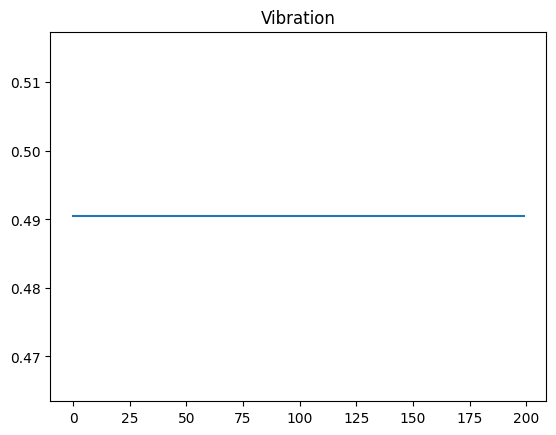

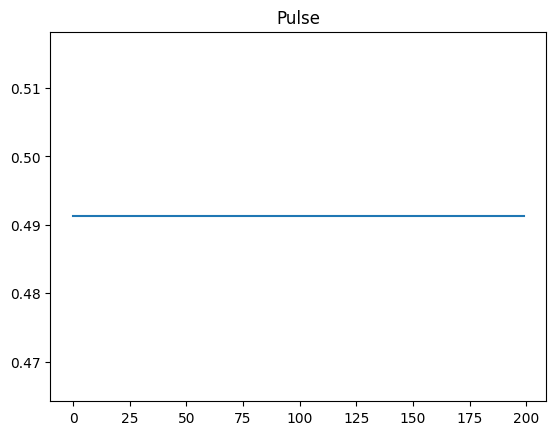

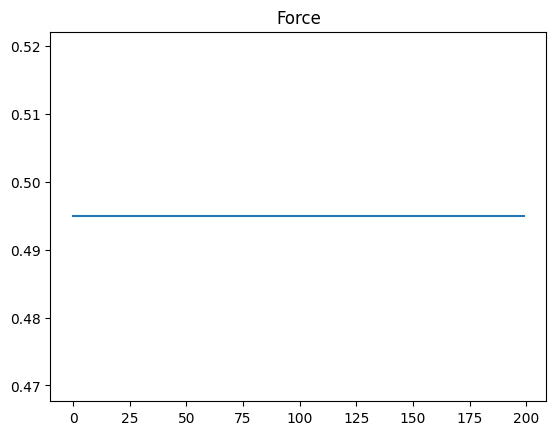

In [74]:
import matplotlib.pyplot as plt
H = out["H_out"].squeeze(0).detach().cpu().numpy()  # (T,3)

plt.figure()
plt.plot(H[:,0]); plt.title("Vibration")
plt.figure()
plt.plot(H[:,1]); plt.title("Pulse")
plt.figure()
plt.plot(H[:,2]); plt.title("Force")
plt.show()


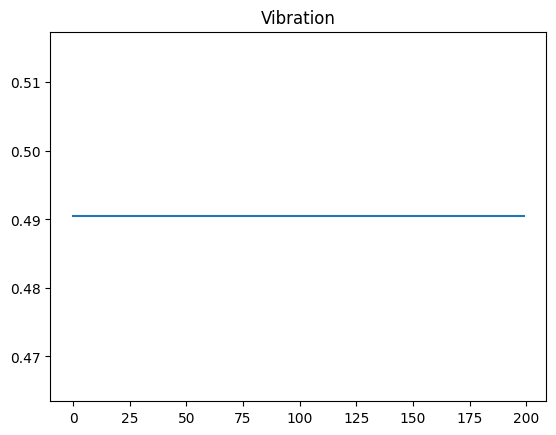

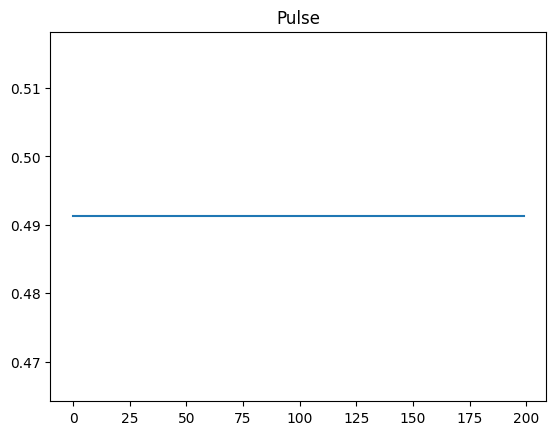

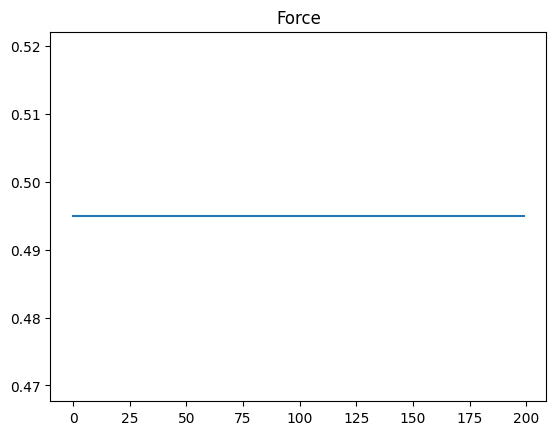

In [75]:
import matplotlib.pyplot as plt
H = out["H_out"].squeeze(0).detach().cpu().numpy()  # (T,3)

plt.figure()
plt.plot(H[:,0]); plt.title("Vibration")
plt.figure()
plt.plot(H[:,1]); plt.title("Pulse")
plt.figure()
plt.plot(H[:,2]); plt.title("Force")
plt.show()

In [76]:
!zip -r /content/filec.zip /content

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/default_configs.db (deflated 98%)
  adding: content/.config/configurations/ (stored 0%)
  adding: content/.config/configurations/config_default (deflated 15%)
  adding: content/.config/.last_survey_prompt.yaml (stored 0%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2026.01.16/ (stored 0%)
  adding: content/.config/logs/2026.01.16/14.23.31.981136.log (deflated 92%)
  adding: content/.config/logs/2026.01.16/14.24.18.954466.log (deflated 58%)
  adding: content/.config/logs/2026.01.16/14.24.03.314209.log (deflated 58%)
  adding: content/.config/logs/2026.01.16/14.24.28.646070.log (deflated 57%)
  adding: content/.config/logs/2026.01.16/14.24.13.071214.log (deflated 87%)
  adding: content/.config/logs/2026.01.16/14.24.29.392089.log (deflated 56%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/hidden_gcloud_config_universe_de

In [77]:
from google.colab import files
files.download("/content/filec.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# HoloSyn Merged Notebook (Clean)
Multimodal encoders + distilled student + **trainable haptics decoder** + UI + export.


## 0) Install
Run once per environment.


In [ ]:
# Install dependencies
!pip -q install brian2 cirq qsimcirq transformers accelerate sentencepiece     openai-whisper ffmpeg-python torchaudio soundfile     open-clip-torch opencv-python decord pillow gradio onnx onnxruntime

import shutil
if shutil.which("ffmpeg") is None:
    print("⚠️ ffmpeg not found. Whisper audio loading requires ffmpeg on your system.")

## 1) Encoder setup
Defines embed_text/embed_images/embed_audio/embed_video.


In [ ]:
# Encoder setup
import torch
import torch.nn.functional as F

torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch_device:", torch_device)

# TEXT
from transformers import AutoTokenizer, AutoModel
TEXT_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
txt_tok = AutoTokenizer.from_pretrained(TEXT_MODEL)
txt_model = AutoModel.from_pretrained(TEXT_MODEL).to(torch_device).eval()

@torch.no_grad()
def embed_text(texts):
    batch = txt_tok(texts, padding=True, truncation=True, return_tensors="pt").to(torch_device)
    out = txt_model(**batch).last_hidden_state
    mask = batch["attention_mask"].unsqueeze(-1)
    pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
    return F.normalize(pooled, dim=-1)

# IMAGE (OpenCLIP)
import open_clip
from PIL import Image
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="laion2b_s34b_b79k"
)
clip_model = clip_model.to(torch_device).eval()

@torch.no_grad()
def embed_images(paths):
    ims = [clip_preprocess(Image.open(p).convert("RGB")) for p in paths]
    x = torch.stack(ims).to(torch_device)
    z = clip_model.encode_image(x)
    return F.normalize(z, dim=-1)

# AUDIO (Whisper encoder mean)
import whisper
whisper_device = "cuda" if torch.cuda.is_available() else "cpu"
wh_model = whisper.load_model("base", device=whisper_device)

@torch.no_grad()
def embed_audio(paths):
    embs = []
    for p in paths:
        audio = whisper.load_audio(p)
        audio = whisper.pad_or_trim(audio)
        mel = whisper.log_mel_spectrogram(audio).to(whisper_device)
        enc = wh_model.encoder(mel.unsqueeze(0))  # (1,frames,dim)
        emb = enc.mean(dim=1).squeeze(0)
        embs.append(emb.to(torch_device))
    embs = torch.stack(embs)
    return F.normalize(embs, dim=-1)

# VIDEO (frames -> CLIP mean)
import decord
import torchvision.transforms as T
decord.bridge.set_bridge("torch")

@torch.no_grad()
def embed_video(paths, num_frames=8):
    all_embs = []
    for p in paths:
        vr = decord.VideoReader(p)
        n = len(vr)
        idx = torch.linspace(0, max(n-1,0), steps=min(num_frames, n)).long()
        frames = vr.get_batch(idx).permute(0,3,1,2)
        frames_pil = [T.ToPILImage()(f.cpu()) for f in frames]
        frames_t = torch.stack([clip_preprocess(im) for im in frames_pil]).to(torch_device)
        zf = clip_model.encode_image(frames_t)
        zv = zf.mean(dim=0)
        all_embs.append(zv)
    all_embs = torch.stack(all_embs)
    return F.normalize(all_embs, dim=-1)

print("✅ Embedding functions ready.")

## 2) Load dataset + synthetic haptics targets


In [ ]:
# Load data + synthetic haptics targets
import os, json, zipfile, shutil
import numpy as np
import soundfile as sf

ZIP_PATH = "/mnt/data/synthdata.zip"
OUT_DIR = "./data_all"
if os.path.exists(OUT_DIR):
    shutil.rmtree(OUT_DIR)
os.makedirs(OUT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(OUT_DIR)

ROOT = os.path.join(OUT_DIR, "synthdata", "synth")
manifest_path = os.path.join(ROOT, "manifest.jsonl")

def fix_path(p):
    if isinstance(p, str) and p.startswith("/content/synth/"):
        rel = p.replace("/content/synth/", "")
        return os.path.join(ROOT, rel)
    return p

def pick(j, *keys):
    for k in keys:
        if k in j and j[k]:
            return j[k]
    return None

items = []
with open(manifest_path, "r", encoding="utf-8") as f:
    for line in f:
        items.append(json.loads(line))

texts, img_paths, aud_paths, vid_paths = [], [], [], []
for j in items:
    texts.append(j.get("text",""))
    img_paths.append(fix_path(pick(j, "image_path","img_path")))
    aud_paths.append(fix_path(pick(j, "audio_path","aud_path")))
    vid_paths.append(fix_path(pick(j, "video_path","vid_path")))

print("N:", len(items))

def synth_haptics(audio_path, text, T=200):
    if audio_path is not None and os.path.exists(audio_path):
        audio, sr = sf.read(audio_path, dtype="float32", always_2d=True)
        wav = audio.mean(axis=1)
        hop = max(1, len(wav) // T)
        env = np.array([np.mean(np.abs(wav[i*hop:(i+1)*hop])) if (i*hop) < len(wav) else 0.0 for i in range(T)], dtype=np.float32)
        env = (env - env.min()) / (env.max() - env.min() + 1e-8)
    else:
        seed = (hash(text) % 10_000_000)
        rng = np.random.default_rng(seed)
        env = rng.random(T, dtype=np.float32)

    pos_hint = float(text.count("!") + text.lower().count("good") + text.lower().count("love"))
    sent = 1.0 / (1.0 + np.exp(-(pos_hint - 1.0)))

    vib   = np.clip(0.15 + 0.85*(0.65*env + 0.35*sent), 0, 1)
    pulse = np.clip((1.0 - sent) * (0.25 + 0.75*env), 0, 1)
    force = np.clip(0.10 + 0.90*(0.75*env + 0.25*sent), 0, 1)
    return np.stack([vib, pulse, force], axis=1).astype(np.float32)

H_T = 200
H_targets = np.stack([synth_haptics(aud_paths[i], texts[i], T=H_T) for i in range(len(items))], axis=0)
print("H_targets:", H_targets.shape, H_targets.min(), H_targets.max())

## 3) Student distilled model


In [ ]:
# Student model definition
import torch
import torch.nn as nn
import torch.nn.functional as F

class StudentDistilledModel(nn.Module):
    def __init__(self, dt, di, da, dv, z=256, hidden=512):
        super().__init__()
        self.text = nn.Sequential(nn.Linear(dt, hidden), nn.ReLU(), nn.Linear(hidden, z))
        self.img  = nn.Sequential(nn.Linear(di, hidden), nn.ReLU(), nn.Linear(hidden, z))
        self.aud  = nn.Sequential(nn.Linear(da, hidden), nn.ReLU(), nn.Linear(hidden, z))
        self.vid  = nn.Sequential(nn.Linear(dv, hidden), nn.ReLU(), nn.Linear(hidden, z))
        self.fuse_gate = nn.Sequential(nn.Linear(z*4 + 4, 256), nn.ReLU(), nn.Linear(256, 4))

    def forward(self, E_t, E_i, E_a, E_v, mask):
        zt = self.text(E_t)
        zi = self.img(E_i)
        za = self.aud(E_a)
        zv = self.vid(E_v)
        z_stack = torch.cat([zt, zi, za, zv], dim=-1)
        g = self.fuse_gate(torch.cat([z_stack, mask], dim=-1))
        g = g.masked_fill(mask == 0, -1e9)
        w = torch.softmax(g, dim=-1)
        Z = w[:,0:1]*zt + w[:,1:2]*zi + w[:,2:3]*za + w[:,3:4]*zv
        return F.normalize(Z, dim=-1), (F.normalize(zt, dim=-1), F.normalize(zi, dim=-1),
                                       F.normalize(za, dim=-1), F.normalize(zv, dim=-1)), w

def save_student(student, path="student_distilled.pt"):
    torch.save({"state_dict": student.state_dict()}, path)
    print("Saved:", path)

def load_student(student, path="student_distilled.pt"):
    ck = torch.load(path, map_location=torch_device)
    student.load_state_dict(ck["state_dict"], strict=True)
    return student

## 4) Train student (fast)


In [ ]:
# Train student
import torch
import torch.nn.functional as F

E_t = embed_text(texts).to(torch_device)
E_i = embed_images(img_paths).to(torch_device)
E_a = embed_audio(aud_paths).to(torch_device)
E_v = embed_video(vid_paths).to(torch_device)

dt, di, da, dv = E_t.shape[1], E_i.shape[1], E_a.shape[1], E_v.shape[1]
print("Dims:", dt, di, da, dv)

Z_target = F.normalize(E_t, dim=-1)

student = StudentDistilledModel(dt, di, da, dv, z=256).to(torch_device)
opt = torch.optim.AdamW(student.parameters(), lr=2e-3, weight_decay=1e-4)
mask = torch.ones((E_t.shape[0], 4), device=torch_device)

def cosine_loss(a, b):
    return 1.0 - (a*b).sum(dim=-1).mean()

student.train()
for epoch in range(1, 4001):
    Zs, _, w = student(E_t, E_i, E_a, E_v, mask)
    loss = cosine_loss(Zs, Z_target)
    opt.zero_grad()
    loss.backward()
    opt.step()
    if epoch % 50 == 0 or epoch == 1:
        print(f"epoch {epoch:4d} loss {loss.item():.4f} w_mean {w.mean(dim=0).detach().cpu().numpy()}")

student.eval()
save_student(student, "student_distilled.pt")

## 5) Real haptics model: trainable decoder (Z -> T×3)


In [ ]:
# Train haptics decoder
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class HapticsDecoder(nn.Module):
    def __init__(self, z_dim=256, hidden=256, out_ch=3):
        super().__init__()
        self.base = nn.Sequential(
            nn.Linear(z_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU()
        )
        self.to_gamma = nn.Linear(hidden, hidden)
        self.to_beta  = nn.Linear(hidden, hidden)
        self.temporal = nn.Sequential(
            nn.Linear(1, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU()
        )
        self.out = nn.Linear(hidden, out_ch)

    def forward(self, Z, T=200):
        h = self.base(Z)  # (B,H)
        gamma = self.to_gamma(h).unsqueeze(1)  # (B,1,H)
        beta  = self.to_beta(h).unsqueeze(1)   # (B,1,H)
        t = torch.linspace(0, 1, T, device=Z.device).view(1, T, 1)
        tfeat = self.temporal(t)  # (1,T,H)
        x = tfeat * (1 + gamma) + beta
        y = torch.sigmoid(self.out(x))  # (B,T,3)
        return y

def save_haptics_decoder(hdec, path="haptics_decoder.pt"):
    torch.save({"state_dict": hdec.state_dict()}, path)
    print("Saved:", path)

def load_haptics_decoder(hdec, path="haptics_decoder.pt"):
    ck = torch.load(path, map_location=torch_device)
    hdec.load_state_dict(ck["state_dict"], strict=True)
    return hdec

student.eval()
with torch.no_grad():
    Zs, _, _ = student(E_t, E_i, E_a, E_v, mask)

H_t = torch.tensor(H_targets, dtype=torch.float32, device=torch_device)

hdec = HapticsDecoder(z_dim=256, hidden=256, out_ch=3).to(torch_device)
opt_h = torch.optim.AdamW(hdec.parameters(), lr=2e-3, weight_decay=1e-4)

hdec.train()
for epoch in range(1, 5001):
    pred = hdec(Zs, T=H_t.shape[1])
    loss = F.mse_loss(pred, H_t)
    opt_h.zero_grad()
    loss.backward()
    opt_h.step()
    if epoch % 50 == 0 or epoch == 1:
        print(f"epoch {epoch:4d} haptics_mse {loss.item():.6f}")

hdec.eval()
save_haptics_decoder(hdec, "haptics_decoder.pt")

## 6) UI + export (student + decoder)


In [ ]:
# Gradio UI + export
import gradio as gr
import tempfile, os, json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F
from datetime import datetime

def _path_from_upload(u):
    if u is None: return None
    if isinstance(u, str): return u
    if isinstance(u, dict) and "name" in u: return u["name"]
    return None

def _blank_image_path():
    blank = Image.new("RGB", (224,224), color=(0,0,0))
    tmp = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
    blank.save(tmp.name)
    return tmp.name

def _cos(a,b):
    a = F.normalize(a, dim=-1); b = F.normalize(b, dim=-1)
    return float((a*b).sum().item())

@torch.no_grad()
def run_ui(text, image, audio, video, T):
    text = "" if text is None else text
    img_path = _path_from_upload(image)
    aud_path = _path_from_upload(audio)
    vid_path = _path_from_upload(video)

    Et = embed_text([text]).to(torch_device)

    if img_path:
        Ei = embed_images([img_path]).to(torch_device); mi=1.0
    else:
        p=_blank_image_path()
        try:
            Ei0 = embed_images([p]).to(torch_device)
        finally:
            try: os.unlink(p)
            except: pass
        Ei = torch.zeros_like(Ei0); mi=0.0

    aud_warn = None
    if aud_path:
        try:
            Ea = embed_audio([aud_path]).to(torch_device); ma=1.0
        except Exception as e:
            Ea = torch.zeros((1, student.aud[0].in_features), device=torch_device); ma=0.0
            aud_warn = str(e)
    else:
        Ea = torch.zeros((1, student.aud[0].in_features), device=torch_device); ma=0.0

    vid_warn = None
    if vid_path:
        try:
            Ev = embed_video([vid_path]).to(torch_device); mv=1.0
        except Exception as e:
            Ev = torch.zeros((1, student.vid[0].in_features), device=torch_device); mv=0.0
            vid_warn = str(e)
    else:
        Ev = torch.zeros((1, student.vid[0].in_features), device=torch_device); mv=0.0

    mask = torch.tensor([[1.0, mi, ma, mv]], device=torch_device)
    Z, (zt, zi, za, zv), w = student(Et, Ei, Ea, Ev, mask)

    sims = {
        "text↔image": _cos(zt, zi) if mi else None,
        "text↔audio": _cos(zt, za) if ma else None,
        "text↔video": _cos(zt, zv) if mv else None,
    }

    H_pred = hdec(Z, T=int(T)).squeeze(0).detach().cpu().numpy()

    fig = plt.figure()
    plt.plot(H_pred[:,0]); plt.title("Predicted haptics: vibration")

    out_npy = "haptics_pred.npy"
    np.save(out_npy, H_pred.astype(np.float32))

    status = "OK"
    warns=[]
    if aud_warn: warns.append("audio embed failed")
    if vid_warn: warns.append("video embed failed")
    if warns:
        status = "OK with warnings: " + " | ".join(warns)

    out = {
        "status": status,
        "Z_shape": list(Z.shape),
        "fusion_weights_[t,i,a,v]": w.detach().cpu().numpy().reshape(-1).tolist(),
        "similarities": sims,
        "Z_preview_16": Z.detach().cpu().numpy().reshape(-1)[:16].round(6).tolist()
    }
    return out, fig, H_pred, out_npy

def export_all(fmt):
    meta = {
        "exported_at": datetime.now().isoformat(),
        "student_dims": {
            "dt": student.text[0].in_features,
            "di": student.img[0].in_features,
            "da": student.aud[0].in_features,
            "dv": student.vid[0].in_features,
            "z": 256
        },
        "haptics": {"channels": ["vibration","pulse","force"]},
        "mask_order": ["text","image","audio","video"],
        "notes": "Exports: student + haptics decoder. Encoders are external."
    }
    meta_path = "export_metadata.json"
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)

    dt,di,da,dv = meta["student_dims"]["dt"], meta["student_dims"]["di"], meta["student_dims"]["da"], meta["student_dims"]["dv"]
    Et = torch.zeros((1, dt), device=torch_device)
    Ei = torch.zeros((1, di), device=torch_device)
    Ea = torch.zeros((1, da), device=torch_device)
    Ev = torch.zeros((1, dv), device=torch_device)
    mask = torch.ones((1,4), device=torch_device)
    Z0 = torch.zeros((1,256), device=torch_device)

    if fmt == "TorchScript":
        st_path = "student_export.torchscript.pt"
        hd_path = "haptics_decoder_export.torchscript.pt"
        torch.jit.trace(student.eval(), (Et, Ei, Ea, Ev, mask)).save(st_path)
        torch.jit.trace(hdec.eval(), (Z0, 200)).save(hd_path)
        return "Exported TorchScript.", st_path, hd_path, meta_path

    st_path = "student_export.onnx"
    hd_path = "haptics_decoder_export.onnx"
    try:
        torch.onnx.export(student.eval(), (Et, Ei, Ea, Ev, mask), st_path,
                          input_names=["E_t","E_i","E_a","E_v","mask"],
                          output_names=["Z","z_tuple","w"], opset_version=17)
        torch.onnx.export(hdec.eval(), (Z0, 200), hd_path,
                          input_names=["Z","T"], output_names=["H"], opset_version=17)
    except Exception as e:
        return f"ONNX export failed: {e}", None, None, meta_path
    return "Exported ONNX.", st_path, hd_path, meta_path

with gr.Blocks() as demo:
    gr.Markdown("## HoloSyn — Distilled Multimodal + Real Haptics
Upload any combo. Output includes predicted haptics + export.")
    text_in = gr.Textbox(label="Text", lines=3)
    with gr.Row():
        img_in = gr.File(label="Image", file_types=["image"])
        aud_in = gr.File(label="Audio", file_types=["audio"])
        vid_in = gr.File(label="Video", file_types=["video"])
    T_in = gr.Slider(50, 500, value=200, step=10, label="Haptics length T")

    with gr.Row():
        run_btn = gr.Button("Run", variant="primary")
        export_fmt = gr.Dropdown(["TorchScript","ONNX"], value="TorchScript", label="Export format")
        export_btn = gr.Button("Export student+decoder")

    out_json = gr.JSON(label="Outputs")
    out_plot = gr.Plot(label="Predicted haptics (vibration)")
    out_arr = gr.Dataframe(label="Predicted haptics array (T x 3)", interactive=False)
    out_npy = gr.File(label="Download haptics (.npy)")

    export_status = gr.Textbox(label="Export status")
    export_student_file = gr.File(label="Student export")
    export_decoder_file = gr.File(label="Haptics decoder export")
    export_meta_file = gr.File(label="Metadata JSON")

    run_btn.click(run_ui, inputs=[text_in, img_in, aud_in, vid_in, T_in], outputs=[out_json, out_plot, out_arr, out_npy])
    export_btn.click(export_all, inputs=[export_fmt], outputs=[export_status, export_student_file, export_decoder_file, export_meta_file])

demo.launch(debug=False, share=False, show_error=True, prevent_thread_lock=True)